# EC-1: Cross-Encoder Reranking for Biomedical Literature Retrieval

**Conversational AI (AIMLCZG521) — EC-1 Assessment, Problem Statement 2**

## Student Details

> **[FILL IN BEFORE SUBMISSION]**
> Name:
> BITS ID:
> Assignment Set: PS2 (confirm against the allotted set before submission)

## Problem Statement

Build and evaluate a **two-stage retrieval system** for biomedical literature:

1. **Stage 1 — initial retrieval.** Given a natural-language research query, retrieve
   a candidate pool of documents from a biomedical corpus using lexical (BM25),
   dense (bi-encoder), and hybrid (Reciprocal Rank Fusion) methods.
2. **Stage 2 — cross-encoder reranking.** Rerank the Stage-1 candidate pool with a
   pretrained cross-encoder that scores each (query, document) pair jointly, and
   evaluate whether reranking improves ranking quality — and at what latency cost.

**Scope statement.** This system performs *literature retrieval* — ranking research
abstracts by relevance to a query. It does **not** provide medical diagnosis,
treatment recommendations, or patient-specific medical advice, and must not be used
for those purposes.

**Self-containment note.** Every function and class used below (BM25, dense
retrieval, RRF fusion, the cross-encoder, all metrics, significance tests, and
analysis logic) is implemented directly in this notebook's code cells — nothing is
imported from an external `src` package. This notebook executes the complete
pipeline live, top to bottom, against the locally cached dataset and model weights.

## Dataset Details and Source

**Dataset:** [BEIR](https://github.com/beir-cellar/beir) / **SciFact**
(Wadden et al., 2020), accessed via HuggingFace `BeIR/scifact` and `BeIR/scifact-qrels`.

| Property | Value |
|---|---|
| Domain | Biomedical / scientific claim verification |
| Corpus | ~5,000 research abstracts (after dedup — see the cleaning summary below) |
| Queries | 300 test-split claims |
| Relevance labels | Binary; almost every query has **exactly one** relevant document |
| Split used | `test` |

**Why SciFact:** small enough to run entirely on CPU, genuinely biomedical, has real
(not synthetic) relevance judgments, and is a standard BEIR benchmark — citable and
comparable to published numbers.

**Binary-label caveat — read this before any metric number in this notebook.**
Because most queries have exactly one relevant document:

| Metric | What it actually measures here |
|---|---|
| **Precision@5** | Capped at **0.20**. Report as a fraction of that ceiling, not as an absolute score. |
| **Recall@5** | Degenerates to a **hit-rate**: 1.0 if the answer is in the top 5, else 0.0. |
| **MRR** | The genuinely informative metric — *where* the answer landed. |
| **nDCG@5** | With binary gains, reduces to a **position-discount** measure. |

A raw P@5 near 0.20 is not a "poor" score — it is close to the ceiling. Every metric
table below should be read against these ceilings, not against a naive 0–1 scale.

## Tools and Libraries Used

| Library | Role |
|---|---|
| `datasets` (HuggingFace) | Load BEIR SciFact |
| `pandas` / `pyarrow` | Data wrangling |
| `transformers` | `AutoTokenizer`, `AutoModelForSequenceClassification` for the cross-encoder |
| `sentence-transformers` | Dense bi-encoder retrieval |
| `torch` | Model inference (MPS on Apple Silicon, else CPU) |
| `rank_bm25`, `pytrec_eval`, `scipy` | **Parity oracles only** — never used in the pipeline itself (General Instruction 9); our BM25, metrics, and significance tests are hand-implemented from their formulas and asserted equal to these |
| `matplotlib` | Figures |
| `yaml` | Loads `config/experiment.yaml`, the single source of truth for experimental constants (not `src` code — a plain data file) |

This notebook is **self-contained**: every function/class it uses (BM25, dense
retrieval, RRF fusion, the cross-encoder with manual tokenization, IR metrics,
significance tests, case-mining, error taxonomy) is defined directly in the code
cells below, not imported from an external package. It only reads two things from
disk: the locally cached SciFact dataset and the locally cached HuggingFace model
weights, plus (optionally) `config/experiment.yaml` for constants.

In [1]:
from __future__ import annotations

import html
import json
import math
import random
import re
import statistics
import time
import unicodedata
from collections import Counter, defaultdict
from contextlib import contextmanager
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Iterable, Mapping, Sequence

import numpy as np
import pandas as pd
import torch
import yaml
from IPython.display import Image, display

pd.set_option("display.max_colwidth", 120)
print("Core imports ready.")

Core imports ready.


In [2]:
# ---------------------------------------------------------------------------
# Configuration — loaded straight from config/experiment.yaml (a data file,
# not src/ code) so every experimental constant lives in one place, matching
# the brief's Experimental Constraint clause. If the yaml isn't found (e.g.
# notebook copied without the repo), fall back to the same constants hardcoded.
# ---------------------------------------------------------------------------
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "config" / "experiment.yaml").exists() and (PROJECT_ROOT.parent / "config" / "experiment.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

_DEFAULT_CONFIG = {
    "seed": 42,
    "dataset": {
        "hf_id": "BeIR/scifact",
        "cache_dir": "data/raw",
        "processed_dir": "data/processed",
    },
    "retrieval": {
        "bm25": {"k1": 1.2, "b": 0.75, "epsilon": 0.25},
        "dense": {"model": "sentence-transformers/all-MiniLM-L6-v2", "batch_size": 64},
        "hybrid": {"rrf_k": 60},
        "top_k_default": 20,
        "candidate_pool_sizes": [5, 10, 20, 50],
        "recall_ceiling_ks": [5, 10, 20, 50, 100],
    },
    "rerank": {
        "models": {
            "primary": "cross-encoder/ms-marco-MiniLM-L-6-v2",
            "comparison": "ncbi/MedCPT-Cross-Encoder",
            "comparison_fallback": "cross-encoder/ms-marco-MiniLM-L-12-v2",
        },
        "batch_size": 16,
        "max_length": 512,
        "truncation": "longest_first",
        "device": "auto",
    },
    "evaluation": {
        "cutoff": 5,
        "bootstrap_samples": 10000,
        "confidence_level": 0.95,
    },
    "timing": {"warmup_runs": 3, "timed_repeats": 5},
    "output": {
        "tables_dir": "results/tables",
        "figures_dir": "results/figures",
        "logs_dir": "results/logs",
    },
}


class Config:
    """Dotted-path access over the YAML config, mirroring the original src/config.py."""

    def __init__(self, data: dict, root: Path = PROJECT_ROOT):
        self._data = data
        self.root = root

    def get(self, path: str, default: Any = None) -> Any:
        node: Any = self._data
        for key in path.split("."):
            if not isinstance(node, dict) or key not in node:
                return default
            node = node[key]
        return node

    def as_dict(self) -> dict:
        return self._data


_config_path = PROJECT_ROOT / "config" / "experiment.yaml"
if _config_path.exists():
    with open(_config_path, "r", encoding="utf-8") as fh:
        cfg = Config(yaml.safe_load(fh))
    print(f"Loaded config from {_config_path}")
else:
    cfg = Config(_DEFAULT_CONFIG)
    print("config/experiment.yaml not found; using inlined default constants.")

SEED = cfg.get("seed", 42)


def resolve_device(requested: str = "auto") -> str:
    if requested != "auto":
        return requested
    if torch.backends.mps.is_available():
        return "mps"
    if torch.cuda.is_available():
        return "cuda"
    return "cpu"


def set_seed(seed: int = SEED, deterministic: bool = True) -> int:
    """Pin every RNG we depend on, for reproducibility across reruns."""
    import os

    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    return seed


set_seed()
DEVICE = resolve_device(cfg.get("rerank.device", "auto"))
print(f"Device: {DEVICE} | Seed: {SEED}")

DATA_CACHE_DIR = str(PROJECT_ROOT / cfg.get("dataset.cache_dir", "data/raw"))
print(f"Dataset cache dir: {DATA_CACHE_DIR}")

Loaded config from /Users/biswa/Downloads/BITS Pilani/sem-3/Conversational AI/biomed-rerank/config/experiment.yaml
Device: mps | Seed: 42
Dataset cache dir: /Users/biswa/Downloads/BITS Pilani/sem-3/Conversational AI/biomed-rerank/data/raw


## Architecture and Workflow

The system is a two-stage cascade: a cheap Stage-1 retriever narrows the corpus to a
candidate pool, and an expensive Stage-2 cross-encoder reorders only that pool.

**Figure 1 — end-to-end architecture** (see `docs/ARCHITECTURE.md` §2 for the full
diagram). The key structural fact: a cross-encoder cannot be Stage 1, because scoring
one pair costs a full transformer forward pass, and doing that for the whole corpus
does not scale. Stage 1 reduces the corpus to K candidates using a scorer that never
sees the query and document jointly; Stage 2 spends its expensive joint-attention
budget only on those K.

**The consequence that governs the whole evaluation:** Stage 2 can only *reorder*
what Stage 1 returned. If the relevant document never made it into the Top-K pool, no
reranker can recover it — Recall@K of the candidate pool is therefore reported as a
hard ceiling before any reranking number (§ Task 5 below).

---
# Task 1 — Data Preparation

Loads BEIR SciFact (corpus, queries, qrels) fresh from the local HuggingFace
`datasets` cache, cleans it, dedups it, and builds two text views:

* `text_norm` — lowercased, punctuation-stripped. What BM25 scores against.
* `text_raw`  — original casing/punctuation preserved. What the dense retriever and
  cross-encoder tokenize (a transformer's WordPiece vocabulary and pretraining both
  assume natural, cased text — lowercasing would destroy the case signal that
  distinguishes a gene symbol like *MDM2* from ordinary prose).

BM25 and BERT want opposite preprocessing (see `docs/ARCHITECTURE.md` §4.1); keeping
both views costs one extra column and removes that confound entirely.

In [3]:
# ---------------------------------------------------------------------------
# Task 1 — inlined data_prep logic (originally src/data_prep.py)
# ---------------------------------------------------------------------------
_WHITESPACE_RE = re.compile(r"\s+")
_HTML_TAG_RE = re.compile(r"<[^>]+>")
_LATEX_INLINE_RE = re.compile(r"\$[^$]*\$")
_LATEX_CMD_RE = re.compile(r"\\[a-zA-Z]+\{[^}]*\}")
_ABBREV_RE = re.compile(r"\b[A-Z]{2,6}\b")


@dataclass
class CleaningStats:
    """Every number here is printed and discussed in the Task 1 write-up."""

    n_corpus_raw: int = 0
    n_corpus_after_dedup: int = 0
    n_duplicates_removed: int = 0
    n_empty_or_missing_abstract: int = 0
    n_title_only_docs: int = 0
    n_html_artifacts_found: int = 0
    n_latex_artifacts_found: int = 0
    n_queries_raw: int = 0
    n_queries_final: int = 0
    n_qrels_raw: int = 0
    n_qrels_final: int = 0
    n_queries_with_multiple_relevant: int = 0
    doc_token_length_summary: dict = field(default_factory=dict)
    n_docs_with_abbreviation: int = 0
    pct_docs_with_abbreviation: float = 0.0

    def as_dict(self) -> dict:
        return self.__dict__.copy()


def _normalize_unicode(text: str) -> str:
    return unicodedata.normalize("NFKC", text)


def _strip_html_and_latex(text: str, stats: CleaningStats) -> str:
    if _HTML_TAG_RE.search(text) or "&" in text:
        stats.n_html_artifacts_found += 1
    if _LATEX_INLINE_RE.search(text) or _LATEX_CMD_RE.search(text):
        stats.n_latex_artifacts_found += 1
    text = html.unescape(text)
    text = _HTML_TAG_RE.sub(" ", text)
    text = _LATEX_INLINE_RE.sub(" ", text)
    text = _LATEX_CMD_RE.sub(" ", text)
    return text


def _collapse_whitespace(text: str) -> str:
    return _WHITESPACE_RE.sub(" ", text).strip()


def clean_text_raw(text: str, stats: CleaningStats) -> str:
    text = _normalize_unicode(text)
    text = _strip_html_and_latex(text, stats)
    return _collapse_whitespace(text)


def clean_text_norm(text_raw: str) -> str:
    return text_raw.lower()


def _title_abstract_hash(title: str, text_norm: str) -> str:
    import hashlib

    key = f"{title.strip().lower()}||{text_norm.strip()}"
    return hashlib.sha256(key.encode("utf-8")).hexdigest()


def load_raw_scifact(cache_dir: str):
    from datasets import load_dataset

    corpus_ds = load_dataset("BeIR/scifact", "corpus", split="corpus", cache_dir=cache_dir)
    queries_ds = load_dataset("BeIR/scifact", "queries", split="queries", cache_dir=cache_dir)
    qrels_ds = load_dataset("BeIR/scifact-qrels", split="test", cache_dir=cache_dir)

    corpus_df = corpus_ds.to_pandas().rename(columns={"_id": "doc_id", "title": "title", "text": "abstract"})
    queries_df = queries_ds.to_pandas().rename(columns={"_id": "query_id", "text": "query_text"})
    qrels_df = qrels_ds.to_pandas().rename(columns={"query-id": "query_id", "corpus-id": "doc_id", "score": "relevance"})

    corpus_df["doc_id"] = corpus_df["doc_id"].astype(str)
    queries_df["query_id"] = queries_df["query_id"].astype(str)
    qrels_df["query_id"] = qrels_df["query_id"].astype(str)
    qrels_df["doc_id"] = qrels_df["doc_id"].astype(str)
    return corpus_df, queries_df, qrels_df


def prepare_corpus(corpus_df: pd.DataFrame, stats: CleaningStats) -> pd.DataFrame:
    stats.n_corpus_raw = len(corpus_df)
    df = corpus_df.copy()
    df["title"] = df["title"].fillna("")
    df["abstract"] = df["abstract"].fillna("")

    stats.n_empty_or_missing_abstract = int((df["abstract"].str.strip() == "").sum())
    stats.n_title_only_docs = stats.n_empty_or_missing_abstract

    # Policy (stated explicitly): title-only records are KEPT, not dropped. A title
    # alone is still a valid, if weak, retrieval signal.
    df["text_raw"] = [clean_text_raw(f"{t} {a}".strip(), stats) for t, a in zip(df["title"], df["abstract"])]
    df["title"] = [clean_text_raw(t, stats) for t in df["title"]]
    df["text_norm"] = df["text_raw"].map(clean_text_norm)

    df["dedup_key"] = [_title_abstract_hash(t, tn) for t, tn in zip(df["title"], df["text_norm"])]
    before = len(df)
    df = df.drop_duplicates(subset="dedup_key", keep="first").drop(columns="dedup_key")
    stats.n_duplicates_removed = before - len(df)
    stats.n_corpus_after_dedup = len(df)

    df["n_tokens"] = df["text_raw"].str.split().str.len()
    df["has_abbrev"] = df["text_raw"].map(lambda t: bool(_ABBREV_RE.search(t)))

    stats.n_docs_with_abbreviation = int(df["has_abbrev"].sum())
    stats.pct_docs_with_abbreviation = 100.0 * stats.n_docs_with_abbreviation / len(df)
    stats.doc_token_length_summary = {
        "mean": float(df["n_tokens"].mean()),
        "median": float(df["n_tokens"].median()),
        "p95": float(df["n_tokens"].quantile(0.95)),
        "max": float(df["n_tokens"].max()),
        "min": float(df["n_tokens"].min()),
        "pct_over_512_tokens": float(100.0 * (df["n_tokens"] > 512).mean()),
    }
    return df.reset_index(drop=True)[["doc_id", "title", "text_raw", "text_norm", "n_tokens", "has_abbrev"]]


def prepare_queries(queries_df: pd.DataFrame, qrels_df: pd.DataFrame, stats: CleaningStats) -> pd.DataFrame:
    stats.n_queries_raw = len(queries_df)
    test_query_ids = set(qrels_df["query_id"].unique())
    df = queries_df[queries_df["query_id"].isin(test_query_ids)].copy()
    df["query_text"] = df["query_text"].fillna("")
    df["query_raw"] = [clean_text_raw(q, stats) for q in df["query_text"]]
    df["query_norm"] = df["query_raw"].map(clean_text_norm)
    df["has_abbrev"] = df["query_raw"].map(lambda t: bool(_ABBREV_RE.search(t)))
    stats.n_queries_final = len(df)
    return df.reset_index(drop=True)[["query_id", "query_raw", "query_norm", "has_abbrev"]]


def prepare_qrels(qrels_df: pd.DataFrame, valid_doc_ids: set, stats: CleaningStats) -> pd.DataFrame:
    stats.n_qrels_raw = len(qrels_df)
    df = qrels_df[qrels_df["doc_id"].isin(valid_doc_ids)].reset_index(drop=True)
    stats.n_qrels_final = len(df)
    per_query = df.groupby("query_id").size()
    stats.n_queries_with_multiple_relevant = int((per_query > 1).sum())
    return df


_EXPANSION_WORD_RE = re.compile(r"[a-zA-Z][a-zA-Z-]{3,}")


def _nearby_expansion_word(text: str, span: tuple, window: int = 30):
    start, end = span
    following = text[end:end + window]
    match = _EXPANSION_WORD_RE.match(following.lstrip("-( ").strip())
    if match:
        return match.group().lower()
    preceding = text[max(0, start - window):start]
    words = _EXPANSION_WORD_RE.findall(preceding)
    return words[-1].lower() if words else None


def find_ambiguous_abbreviations(corpus, min_expansions=2, min_occurrences=3, max_occurrences=40, top_n=10):
    """Surface real abbreviations from *this* corpus with >1 distinct nearby content
    word -- concrete evidence for the 'similar terminology in unrelated research'
    discussion point, grounded in our own data rather than a generic claim."""
    contexts = defaultdict(set)
    occurrences = defaultdict(int)
    for text in corpus["text_raw"]:
        for match in _ABBREV_RE.finditer(text):
            abbrev = match.group()
            occurrences[abbrev] += 1
            expansion_word = _nearby_expansion_word(text, match.span())
            if expansion_word:
                contexts[abbrev].add(expansion_word)

    candidates = [
        {
            "abbreviation": abbrev,
            "n_occurrences": occurrences[abbrev],
            "n_distinct_nearby_words": len(ctx_set),
            "sample_nearby_words": sorted(ctx_set)[:8],
        }
        for abbrev, ctx_set in contexts.items()
        if len(ctx_set) >= min_expansions and min_occurrences <= occurrences[abbrev] <= max_occurrences
    ]
    candidates.sort(key=lambda c: c["n_distinct_nearby_words"] / c["n_occurrences"], reverse=True)
    return candidates[:top_n]


print("Task 1 functions defined.")

Task 1 functions defined.


In [4]:
# ---------------------------------------------------------------------------
# Task 1 — run: load SciFact fresh from the local cache, clean, dedup
# ---------------------------------------------------------------------------
t0 = time.perf_counter()
corpus_raw, queries_raw, qrels_raw = load_raw_scifact(DATA_CACHE_DIR)
print(f"Loaded raw SciFact in {time.perf_counter() - t0:.1f}s: "
      f"{len(corpus_raw)} corpus docs, {len(queries_raw)} queries, {len(qrels_raw)} qrel rows")

stats = CleaningStats()
corpus = prepare_corpus(corpus_raw, stats)
queries = prepare_queries(queries_raw, qrels_raw, stats)
qrels_df = prepare_qrels(qrels_raw, set(corpus["doc_id"]), stats)

qrels: dict = {}
for row in qrels_df.itertuples():
    qrels.setdefault(row.query_id, {})[row.doc_id] = float(row.relevance)

print("=== Task 1: Data Preparation Summary ===")
for key, value in stats.as_dict().items():
    print(f"{key:38s} {value}")
print(f"\nFinal: {len(corpus)} docs, {len(queries)} queries, {len(qrels_df)} qrels")

Loaded raw SciFact in 9.8s: 5183 corpus docs, 1109 queries, 339 qrel rows


=== Task 1: Data Preparation Summary ===
n_corpus_raw                           5183
n_corpus_after_dedup                   5183
n_duplicates_removed                   0
n_empty_or_missing_abstract            0
n_title_only_docs                      0
n_html_artifacts_found                 138
n_latex_artifacts_found                18
n_queries_raw                          1109
n_queries_final                        300
n_qrels_raw                            339
n_qrels_final                          339
n_queries_with_multiple_relevant       23
doc_token_length_summary               {'mean': 213.93594443372564, 'median': 204.0, 'p95': 353.0, 'max': 1541.0, 'min': 33.0, 'pct_over_512_tokens': 0.6752845842176346}
n_docs_with_abbreviation               4184
pct_docs_with_abbreviation             80.72544858190237

Final: 5183 docs, 300 queries, 339 qrels


In [5]:
print("=== Sample ambiguous abbreviations from this corpus ===")
ambiguous_abbrevs = find_ambiguous_abbreviations(corpus, top_n=5)
for cand in ambiguous_abbrevs:
    print(cand)

=== Sample ambiguous abbreviations from this corpus ===
{'abbreviation': 'GSC', 'n_occurrences': 3, 'n_distinct_nearby_words': 3, 'sample_nearby_words': ['divisions', 'growth', 'survival']}
{'abbreviation': 'ABPI', 'n_occurrences': 6, 'n_distinct_nearby_words': 6, 'sample_nearby_words': ['between', 'conclusion', 'correlated', 'index', 'were', 'with']}
{'abbreviation': 'MODS', 'n_occurrences': 3, 'n_distinct_nearby_words': 3, 'sample_nearby_words': ['against', 'indicators', 'syndrome']}
{'abbreviation': 'YFP', 'n_occurrences': 3, 'n_distinct_nearby_words': 3, 'sample_nearby_words': ['expression', 'eyfp', 'reporter']}
{'abbreviation': 'PEPCK', 'n_occurrences': 3, 'n_distinct_nearby_words': 3, 'sample_nearby_words': ['carboxykinase', 'enzymes', 'including']}


### Task 1 — Discussion

- **Why preprocessing matters for biomedical retrieval:** BM25 and a transformer
  encoder want *opposite* preprocessing — BM25 matches surface term forms and
  benefits from lowercasing, while a transformer's WordPiece vocabulary and
  pretraining assume natural, cased text (lowercasing destroys the signal that
  distinguishes a gene symbol like *MDM2* from ordinary prose). We therefore keep two
  views, `text_norm` and `text_raw`, rather than compromising on one.
- **Challenges of long scientific abstracts:** the token-length summary printed above
  (`doc_token_length_summary`) shows the corpus's `pct_over_512_tokens` — the fraction
  of documents that would be truncated by a 512-token cross-encoder. This sets up the
  truncation question revisited quantitatively in Task 7.
- **Medical terminology, abbreviations, named entities:** `n_docs_with_abbreviation`
  and `pct_docs_with_abbreviation` above quantify how common all-caps 2–6 letter
  abbreviations are across this corpus.
- **Similar terminology in unrelated research:** the `ambiguous_abbrevs` list printed
  above surfaces real abbreviations from *this* corpus that co-occur with more than
  one distinct nearby content word — i.e., abbreviations that plausibly mean different
  things in different documents (a concrete example of the "similar terminology,
  unrelated research" ambiguity problem, grounded in the data rather than asserted
  generically).

---
# Task 2 — Initial Search System (Stage 1: BM25, Dense, Hybrid)

BM25 implemented from the Robertson–Zaragoza formula directly (not a library call);
dense retrieval via a sentence-transformer bi-encoder; hybrid via Reciprocal Rank
Fusion (RRF). Run live over all 300 test queries below.

In [6]:
# ---------------------------------------------------------------------------
# Task 2 — inlined BM25 (originally src/retrieval/bm25.py)
#
# score(q, d) = sum_over_terms_t_in_q [ idf(t) * f(t, d) * (k1 + 1) ]
#                                     / [ f(t, d) + k1 * (1 - b + b * |d| / avgdl) ]
# idf(t) = log( (N - n(t) + 0.5) / (n(t) + 0.5) )   floored per rank_bm25 convention
# ---------------------------------------------------------------------------
_TOKEN_RE = re.compile(r"[a-z0-9]+")


def tokenize(text: str) -> list:
    """Lowercase alphanumeric tokenizer -- deliberately crude (no stemming, no
    stopword removal) so the BM25-vs-dense comparison isn\'t confounded by a second,
    undocumented preprocessing difference."""
    return _TOKEN_RE.findall(text.lower())


@dataclass
class ScoredDocBM25:
    doc_id: str
    score: float


class BM25:
    """Okapi BM25 over a fixed corpus, scored from the formula above."""

    def __init__(self, k1: float = 1.2, b: float = 0.75, epsilon: float = 0.25):
        self.k1 = k1
        self.b = b
        self.epsilon = epsilon
        self.doc_ids = []
        self.doc_freqs = []
        self.doc_lens = []
        self.avgdl = 0.0
        self.idf = {}

    def index(self, doc_ids, tokenized_docs):
        if len(doc_ids) != len(tokenized_docs):
            raise ValueError("doc_ids and tokenized_docs must be the same length")
        self.doc_ids = list(doc_ids)
        self.doc_freqs = [Counter(tokens) for tokens in tokenized_docs]
        self.doc_lens = [len(tokens) for tokens in tokenized_docs]
        self.avgdl = sum(self.doc_lens) / len(self.doc_lens) if self.doc_lens else 0.0

        n_docs = len(self.doc_ids)
        df = Counter()
        for freqs in self.doc_freqs:
            for term in freqs:
                df[term] += 1

        raw_idf = {term: math.log(n_docs - freq + 0.5) - math.log(freq + 0.5) for term, freq in df.items()}
        avg_idf = sum(raw_idf.values()) / len(raw_idf) if raw_idf else 0.0
        eps_floor = self.epsilon * avg_idf
        self.idf = {term: (score if score > 0 else eps_floor) for term, score in raw_idf.items()}
        return self

    def score(self, query_tokens, doc_index: int) -> float:
        freqs = self.doc_freqs[doc_index]
        doc_len = self.doc_lens[doc_index]
        norm = 1 - self.b + self.b * (doc_len / self.avgdl if self.avgdl else 0.0)
        total = 0.0
        for term in query_tokens:
            if term not in freqs:
                continue
            f = freqs[term]
            idf = self.idf.get(term, 0.0)
            total += idf * f * (self.k1 + 1) / (f + self.k1 * norm)
        return total

    def score_all(self, query_tokens):
        query_tokens = list(query_tokens)
        return [self.score(query_tokens, i) for i in range(len(self.doc_ids))]

    def search(self, query_text: str, top_k: int = 20):
        query_tokens = tokenize(query_text)
        scores = self.score_all(query_tokens)
        ranked = sorted(zip(self.doc_ids, scores), key=lambda pair: pair[1], reverse=True)[:top_k]
        return [ScoredDocBM25(doc_id, score) for doc_id, score in ranked]


print("BM25 defined.")

BM25 defined.


In [7]:
# ---------------------------------------------------------------------------
# Task 2 -- inlined dense bi-encoder retrieval (originally src/retrieval/dense.py)
# ---------------------------------------------------------------------------
@dataclass
class ScoredDocDense:
    doc_id: str
    score: float


class DenseRetriever:
    """Sentence-embedding bi-encoder retrieval over a fixed corpus. Encodes the whole
    corpus once into an L2-normalised embedding matrix; a query score is then a single
    dot product -- the precomputability that makes bi-encoder retrieval scale."""

    def __init__(self, model_name: str = None, device: str = None, batch_size: int = 64):
        from sentence_transformers import SentenceTransformer

        self.model_name = model_name or cfg.get("retrieval.dense.model")
        self.device = device or DEVICE
        self.batch_size = batch_size
        self.model = SentenceTransformer(self.model_name, device=self.device)
        self.doc_ids = []
        self.doc_embeddings = None

    def index(self, doc_ids, texts):
        if len(doc_ids) != len(texts):
            raise ValueError("doc_ids and texts must be the same length")
        self.doc_ids = list(doc_ids)
        self.doc_embeddings = self.model.encode(
            list(texts), batch_size=self.batch_size, normalize_embeddings=True,
            convert_to_numpy=True, show_progress_bar=False,
        ).astype(np.float32)
        return self

    def score_all(self, query_text: str):
        if self.doc_embeddings is None:
            raise RuntimeError("call .index() before scoring")
        query_vec = self.model.encode(
            [query_text], normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=False
        )[0].astype(np.float32)
        return self.doc_embeddings @ query_vec

    def search(self, query_text: str, top_k: int = 20):
        scores = self.score_all(query_text)
        top_idx = np.argsort(-scores)[:top_k]
        return [ScoredDocDense(self.doc_ids[i], float(scores[i])) for i in top_idx]


print("DenseRetriever defined.")

DenseRetriever defined.


In [8]:
# ---------------------------------------------------------------------------
# Task 2 -- inlined hybrid RRF fusion (originally src/retrieval/hybrid.py)
#
# rrf_score(d) = sum over rankers r that retrieved d of  1 / (k + rank_r(d))
# Rank position only -- sidesteps score-calibration issues between BM25"s unbounded
# scores and dense"s bounded cosine similarities. k=60 per Cormack et al. (2009).
# ---------------------------------------------------------------------------
@dataclass
class ScoredDocHybrid:
    doc_id: str
    score: float


def reciprocal_rank_fusion(rankings, k: int = 60, top_k: int = 20):
    fused = {}
    for ranking in rankings:
        for rank, scored_doc in enumerate(ranking, start=1):
            fused[scored_doc.doc_id] = fused.get(scored_doc.doc_id, 0.0) + 1.0 / (k + rank)
    ranked = sorted(fused.items(), key=lambda pair: pair[1], reverse=True)[:top_k]
    return [ScoredDocHybrid(doc_id, score) for doc_id, score in ranked]


class HybridRetriever:
    """Fuses a BM25 and a dense retriever via RRF. Each is queried for a wider pool
    (fusion_pool) than the final top_k, so RRF has enough overlap to fuse meaningfully."""

    def __init__(self, bm25, dense, rrf_k: int = 60, fusion_pool: int = 100):
        self.bm25 = bm25
        self.dense = dense
        self.rrf_k = rrf_k
        self.fusion_pool = fusion_pool

    def search(self, query_text: str, top_k: int = 20):
        bm25_results = self.bm25.search(query_text, top_k=self.fusion_pool)
        dense_results = self.dense.search(query_text, top_k=self.fusion_pool)
        return reciprocal_rank_fusion([bm25_results, dense_results], k=self.rrf_k, top_k=top_k)


print("HybridRetriever defined.")

HybridRetriever defined.


### BM25-vs-`rank_bm25` parity — evidence for General Instruction 9

Our BM25 is scored from the formula, not from a library. This cell proves it matches
the reference implementation (`rank_bm25`, used **only** as a test oracle here) within
numerical tolerance.

In [9]:
# Parity check: our BM25 vs. rank_bm25 (oracle only, not used in the pipeline).
from rank_bm25 import BM25Okapi

_sample_docs = corpus["text_norm"].head(300).tolist()
_sample_doc_ids = corpus["doc_id"].head(300).tolist()
_sample_tokenized = [tokenize(t) for t in _sample_docs]

_our_bm25 = BM25(
    k1=cfg.get("retrieval.bm25.k1", 1.2),
    b=cfg.get("retrieval.bm25.b", 0.75),
    epsilon=cfg.get("retrieval.bm25.epsilon", 0.25),
).index(_sample_doc_ids, _sample_tokenized)

_oracle_bm25 = BM25Okapi(
    _sample_tokenized,
    k1=cfg.get("retrieval.bm25.k1", 1.2),
    b=cfg.get("retrieval.bm25.b", 0.75),
    epsilon=cfg.get("retrieval.bm25.epsilon", 0.25),
)

_sample_query_tokens = tokenize(queries.iloc[0]["query_raw"])
_our_scores = np.array(_our_bm25.score_all(_sample_query_tokens))
_oracle_scores = np.array(_oracle_bm25.get_scores(_sample_query_tokens))

_max_abs_diff = float(np.max(np.abs(_our_scores - _oracle_scores)))
print(f"Max abs difference vs. rank_bm25 over {len(_sample_doc_ids)} docs: {_max_abs_diff:.2e}")
assert _max_abs_diff < 1e-6, "BM25 implementation diverges from rank_bm25 oracle"
print("PASS: our BM25 scoring matches rank_bm25 within 1e-6.")

Max abs difference vs. rank_bm25 over 300 docs: 8.88e-16
PASS: our BM25 scoring matches rank_bm25 within 1e-6.


In [10]:
# ---------------------------------------------------------------------------
# Task 2 -- build indices and run all three Stage-1 retrievers over all 300 queries
# ---------------------------------------------------------------------------
print(f"Corpus: {len(corpus)} docs | Queries: {len(queries)} | Building indices...")

bm25 = BM25(
    k1=cfg.get("retrieval.bm25.k1", 1.2),
    b=cfg.get("retrieval.bm25.b", 0.75),
    epsilon=cfg.get("retrieval.bm25.epsilon", 0.25),
)
bm25.index(corpus["doc_id"].tolist(), [tokenize(t) for t in corpus["text_norm"]])

dense = DenseRetriever(
    model_name=cfg.get("retrieval.dense.model"),
    batch_size=cfg.get("retrieval.dense.batch_size", 64),
)
dense.index(corpus["doc_id"].tolist(), corpus["text_raw"].tolist())

hybrid = HybridRetriever(bm25, dense, rrf_k=cfg.get("retrieval.hybrid.rrf_k", 60))
print("Indices built.")

Corpus: 5183 docs | Queries: 300 | Building indices...


Indices built.


In [11]:
class StageTimer:
    """Accumulates per-stage latencies across many queries."""

    def __init__(self):
        self.records = {}

    @contextmanager
    def stage(self, name: str):
        start = time.perf_counter()
        try:
            yield
        finally:
            elapsed_ms = (time.perf_counter() - start) * 1000.0
            self.records.setdefault(name, []).append(elapsed_ms)


def _percentile(values, pct: float) -> float:
    if not values:
        raise ValueError("cannot take a percentile of an empty sample")
    if len(values) == 1:
        return values[0]
    ordered = sorted(values)
    pos = (len(ordered) - 1) * (pct / 100.0)
    lower = int(pos)
    upper = min(lower + 1, len(ordered) - 1)
    weight = pos - lower
    return ordered[lower] * (1 - weight) + ordered[upper] * weight


@dataclass
class TimingResult:
    label: str
    p50_ms: float
    p95_ms: float
    mean_ms: float
    min_ms: float
    max_ms: float
    n_runs: int

    def as_row(self):
        return {
            "operation": self.label, "p50_ms": round(self.p50_ms, 3), "p95_ms": round(self.p95_ms, 3),
            "mean_ms": round(self.mean_ms, 3), "min_ms": round(self.min_ms, 3),
            "max_ms": round(self.max_ms, 3), "n_runs": self.n_runs,
        }


def measure(fn, label: str, warmup: int = 3, repeats: int = 5):
    for _ in range(warmup):
        fn()
    samples = []
    result = None
    for _ in range(repeats):
        start = time.perf_counter()
        result = fn()
        samples.append((time.perf_counter() - start) * 1000.0)
    return result, TimingResult(
        label=label, p50_ms=_percentile(samples, 50), p95_ms=_percentile(samples, 95),
        mean_ms=statistics.fmean(samples), min_ms=min(samples), max_ms=max(samples), n_runs=repeats,
    )


def run_all_queries(retriever, queries_df, text_col, top_k, timer, stage_name):
    run = {}
    for row in queries_df.itertuples():
        query_text = getattr(row, text_col)
        with timer.stage(stage_name):
            results = retriever.search(query_text, top_k=top_k)
        run[row.query_id] = [sd.doc_id for sd in results]
    return run


top_k_default = cfg.get("retrieval.top_k_default", 20)
recall_ceiling_ks = cfg.get("retrieval.recall_ceiling_ks", [5, 10, 20, 50, 100])
max_k = max(top_k_default, *recall_ceiling_ks)
timer1 = StageTimer()

print("Running BM25 over all queries...")
bm25_run = run_all_queries(bm25, queries, "query_norm", max_k, timer1, "bm25")
print("Running dense retrieval over all queries...")
dense_run = run_all_queries(dense, queries, "query_raw", max_k, timer1, "dense")
print("Running hybrid (RRF) over all queries...")
hybrid_run = run_all_queries(hybrid, queries, "query_raw", max_k, timer1, "hybrid")
print("Stage-1 retrieval complete for all three methods.")

Running BM25 over all queries...


Running dense retrieval over all queries...


Running hybrid (RRF) over all queries...


Stage-1 retrieval complete for all three methods.


In [12]:
# Latency: warmed-up single-query measurement (3 warmup, 5 timed repeats).
warmup = cfg.get("timing.warmup_runs", 3)
repeats = cfg.get("timing.timed_repeats", 5)
_sample_query = queries.iloc[0]

_, bm25_timing = measure(lambda: bm25.search(_sample_query.query_norm, top_k_default), "bm25", warmup, repeats)
_, dense_timing = measure(lambda: dense.search(_sample_query.query_raw, top_k_default), "dense", warmup, repeats)
_, hybrid_timing = measure(lambda: hybrid.search(_sample_query.query_raw, top_k_default), "hybrid", warmup, repeats)

stage1_latency = pd.DataFrame([bm25_timing.as_row(), dense_timing.as_row(), hybrid_timing.as_row()])
print("=== Stage-1 latency (ms) ===")
print(stage1_latency.to_string(index=False))

=== Stage-1 latency (ms) ===
operation  p50_ms  p95_ms  mean_ms  min_ms  max_ms  n_runs
     bm25   3.237   3.912    3.442   3.192   4.002       5
    dense   9.847  11.062   10.002   9.103  11.319       5
   hybrid  12.851  13.277   12.890  12.577  13.333       5


In [13]:
# ---------------------------------------------------------------------------
# Task 2 -- hand-rolled IR metrics, used here and reused (inlined again) in Task 5
# ---------------------------------------------------------------------------
def precision_at_k(ranking, relevant, k: int) -> float:
    if k <= 0:
        raise ValueError("k must be positive")
    hits = sum(1 for doc_id in ranking[:k] if relevant.get(doc_id, 0) > 0)
    return hits / k


def precision_at_k_ceiling(relevant, k: int) -> float:
    n_relevant = sum(1 for score in relevant.values() if score > 0)
    return min(n_relevant, k) / k


def recall_at_k(ranking, relevant, k: int) -> float:
    if k <= 0:
        raise ValueError("k must be positive")
    n_relevant = sum(1 for score in relevant.values() if score > 0)
    if n_relevant == 0:
        return 0.0
    hits = sum(1 for doc_id in ranking[:k] if relevant.get(doc_id, 0) > 0)
    return hits / n_relevant


def reciprocal_rank(ranking, relevant, k=None) -> float:
    considered = ranking if k is None else ranking[:k]
    for position, doc_id in enumerate(considered, start=1):
        if relevant.get(doc_id, 0) > 0:
            return 1.0 / position
    return 0.0


def dcg_at_k(gains, k: int) -> float:
    """Linear-gain trec_eval convention: gain / log2(rank+1). Matches pytrec_eval\'s
    ndcg_cut, NOT the exponential-gain web-IR form (the two coincide under binary
    relevance, which is why this only matters for graded relevance)."""
    return sum(gain / math.log2(position + 1) for position, gain in enumerate(list(gains)[:k], start=1))


def ndcg_at_k(ranking, relevant, k: int) -> float:
    if k <= 0:
        raise ValueError("k must be positive")
    actual_gains = [float(relevant.get(doc_id, 0)) for doc_id in ranking[:k]]
    ideal_gains = sorted((s for s in relevant.values() if s > 0), reverse=True)
    idcg = dcg_at_k(ideal_gains, k)
    if idcg == 0.0:
        return 0.0
    return dcg_at_k(actual_gains, k) / idcg


def evaluate_query(ranking, relevant, k: int = 5) -> dict:
    return {
        f"precision@{k}": precision_at_k(ranking, relevant, k),
        f"precision@{k}_ceiling": precision_at_k_ceiling(relevant, k),
        f"recall@{k}": recall_at_k(ranking, relevant, k),
        "mrr": reciprocal_rank(ranking, relevant),
        f"ndcg@{k}": ndcg_at_k(ranking, relevant, k),
    }


def evaluate_run(run, qrels_map, k: int = 5, skip_unjudged: bool = True) -> dict:
    per_query = {}
    for query_id, ranking in run.items():
        relevant = qrels_map.get(query_id, {})
        if skip_unjudged and not any(score > 0 for score in relevant.values()):
            continue
        per_query[query_id] = evaluate_query(ranking, relevant, k)
    return per_query


def aggregate(per_query: dict) -> dict:
    if not per_query:
        return {}
    metric_names = next(iter(per_query.values())).keys()
    means = {name: sum(scores[name] for scores in per_query.values()) / len(per_query) for name in metric_names}
    for name in list(means):
        if name.endswith("_ceiling"):
            base = name.removesuffix("_ceiling")
            ceiling = means[name]
            if ceiling > 0:
                means[f"{base}_pct_of_ceiling"] = means[base] / ceiling
    means["n_queries"] = len(per_query)
    return means


def compare_runs(baseline: dict, treatment: dict, metric: str = "ndcg@5") -> dict:
    shared = sorted(set(baseline) & set(treatment))
    if not shared:
        raise ValueError("runs share no query ids")
    deltas = [treatment[q][metric] - baseline[q][metric] for q in shared]
    improved = sum(1 for d in deltas if d > 1e-9)
    degraded = sum(1 for d in deltas if d < -1e-9)
    return {
        "metric": metric, "n_queries": len(shared),
        "baseline_mean": sum(baseline[q][metric] for q in shared) / len(shared),
        "treatment_mean": sum(treatment[q][metric] for q in shared) / len(shared),
        "mean_delta": sum(deltas) / len(deltas),
        "n_improved": improved, "n_degraded": degraded, "n_unchanged": len(deltas) - improved - degraded,
        "pct_improved": 100.0 * improved / len(deltas), "pct_degraded": 100.0 * degraded / len(deltas),
    }


def recall_ceiling(run: dict, qrels_map: dict, ks=(5, 10, 20, 50, 100)) -> list:
    """Recall@K of the candidate pool -- a hard upper bound on any post-rerank metric,
    since a reranker can only reorder what Stage 1 retrieved."""
    rows = []
    for k in ks:
        scored = [
            recall_at_k(ranking, qrels_map.get(qid, {}), k)
            for qid, ranking in run.items()
            if any(s > 0 for s in qrels_map.get(qid, {}).values())
        ]
        if not scored:
            continue
        rows.append({
            "k": k, "recall@k": sum(scored) / len(scored), "n_queries": len(scored),
            "pct_queries_with_hit": 100.0 * sum(1 for s in scored if s > 0) / len(scored),
        })
    return rows


print("Metrics functions defined.")

Metrics functions defined.


In [14]:
metrics_k = cfg.get("evaluation.cutoff", 5)
_stage1_results = {}
for name, run in [("bm25", bm25_run), ("dense", dense_run), ("hybrid", hybrid_run)]:
    per_query = evaluate_run(run, qrels, k=metrics_k)
    _stage1_results[name] = aggregate(per_query)
stage1_metrics = pd.DataFrame(_stage1_results).T.reset_index().rename(columns={"index": "method"})

print(f"=== Stage-1 metrics @k={metrics_k} ===")
print(stage1_metrics.to_string(index=False))

=== Stage-1 metrics @k=5 ===
method  precision@5  precision@5_ceiling  recall@5      mrr   ndcg@5  precision@5_pct_of_ceiling  n_queries
  bm25     0.156000                0.226  0.721778 0.625976 0.635209                    0.690265      300.0
 dense     0.164000                0.226  0.737944 0.611522 0.629551                    0.725664      300.0
hybrid     0.164667                0.226  0.746167 0.664474 0.669363                    0.728614      300.0


In [15]:
_ceiling_rows = []
for name, run in [("bm25", bm25_run), ("dense", dense_run), ("hybrid", hybrid_run)]:
    for row in recall_ceiling(run, qrels, ks=recall_ceiling_ks):
        row["method"] = name
        _ceiling_rows.append(row)
stage1_ceiling = pd.DataFrame(_ceiling_rows)

print("=== Stage-1 recall ceiling (headroom for reranking) ===")
print(stage1_ceiling.pivot(index="k", columns="method", values="recall@k").to_string())

=== Stage-1 recall ceiling (headroom for reranking) ===
method      bm25     dense    hybrid
k                                   
5       0.721778  0.737944  0.746167
10      0.775667  0.786667  0.802556
20      0.831611  0.837333  0.873056
50      0.865722  0.892000  0.939667
100     0.876389  0.925000  0.957000


### Lexical mismatch and semantic drift — concrete examples, mined from this run

- **Lexical mismatch**: the relevant document is missing/low from BM25 (surface-term
  matching) but present/high in dense retrieval (semantic similarity) — a synonym or
  paraphrase BM25's exact-term matching cannot bridge.
- **Semantic drift**: dense retrieval ranks a *non-relevant* but topically-similar
  document highly — the failure mode a bi-encoder is prone to since it can only
  compare independently-produced summaries, never the query and document jointly.

In [16]:
def mine_lexical_mismatch(bm25_run, dense_run, qrels_map, queries_df, corpus_df, top_n=5):
    corpus_lookup = corpus_df.set_index("doc_id")
    rows = []
    for row in queries_df.itertuples():
        qid = row.query_id
        relevant = {d for d, s in qrels_map.get(qid, {}).items() if s > 0}
        if not relevant:
            continue
        bm25_ranking = bm25_run.get(qid, [])
        dense_ranking = dense_run.get(qid, [])
        for doc_id in relevant:
            bm25_rank = bm25_ranking.index(doc_id) + 1 if doc_id in bm25_ranking else None
            dense_rank = dense_ranking.index(doc_id) + 1 if doc_id in dense_ranking else None
            if dense_rank is not None and dense_rank <= 5 and (bm25_rank is None or bm25_rank > 15):
                rows.append({
                    "query_id": qid, "query": row.query_raw, "doc_id": doc_id,
                    "doc_title": corpus_lookup.loc[doc_id, "title"] if doc_id in corpus_lookup.index else "",
                    "bm25_rank": bm25_rank or "not in top-100", "dense_rank": dense_rank,
                })
    return pd.DataFrame(rows).head(top_n)


def mine_semantic_drift(dense_run, qrels_map, queries_df, corpus_df, top_n=5):
    corpus_lookup = corpus_df.set_index("doc_id")
    rows = []
    for row in queries_df.itertuples():
        qid = row.query_id
        relevant = {d for d, s in qrels_map.get(qid, {}).items() if s > 0}
        for rank, doc_id in enumerate(dense_run.get(qid, [])[:3], start=1):
            if doc_id not in relevant:
                rows.append({
                    "query_id": qid, "query": row.query_raw, "doc_id": doc_id,
                    "doc_title": corpus_lookup.loc[doc_id, "title"] if doc_id in corpus_lookup.index else "",
                    "dense_rank": rank,
                })
    return pd.DataFrame(rows).head(top_n)


lexical_mismatch = mine_lexical_mismatch(bm25_run, dense_run, qrels, queries, corpus)
semantic_drift = mine_semantic_drift(dense_run, qrels, queries, corpus)

print(f"Lexical mismatch candidates found: {len(lexical_mismatch)}")
display(lexical_mismatch)
print(f"\nSemantic drift candidates found: {len(semantic_drift)}")
display(semantic_drift)

Lexical mismatch candidates found: 5


,query_id,query,doc_id,doc_title,bm25_rank,dense_rank
0,1,0-dimensional biomaterials show inductive properties.,31715818,New opportunities: the use of nanotechnologies to manipulate and track stem cells.,not in top-100,5
1,133,"Assembly of invadopodia is triggered by focal generation of phosphatidylinositol-3,4-biphosphate and the activation ...",17934082,Membrane lipids in invadopodia and podosomes: Key structures for cancer invasion and metastasis,22,3
2,179,Birth-weight is positively associated with breast cancer.,27123743,Role of birthweight in the etiology of breast cancer.,not in top-100,1
3,179,Birth-weight is positively associated with breast cancer.,23557241,Intrauterine factors and risk of breast cancer: a systematic review and meta-analysis of current evidence.,20,5
4,238,Cells undergoing methionine restriction may activate miRNAs.,2251426,microRNAs: A Safeguard against Turmoil?,20,2



Semantic drift candidates found: 5


,query_id,query,doc_id,doc_title,dense_rank
0,1,0-dimensional biomaterials show inductive properties.,29638116,Complex Tissue and Disease Modeling using hiPSCs.,1
1,1,0-dimensional biomaterials show inductive properties.,4346436,Nonlinear Elasticity in Biological Gels,2
2,1,0-dimensional biomaterials show inductive properties.,3874000,Tissue Mechanics Orchestrate Wnt-Dependent Human Embryonic Stem Cell Differentiation.,3
3,3,"1,000 genomes project enables mapping of genetic sequence variation consisting of rare variants with larger penetran...",2739854,Rare and common variants: twenty arguments,1
4,3,"1,000 genomes project enables mapping of genetic sequence variation consisting of rare variants with larger penetran...",23389795,Common and rare variants in multifactorial susceptibility to common diseases,2


### Task 2 — Discussion

- **Advantages / limitations per method:**
  - *BM25* — exact surface-term matching; fast, interpretable, no training needed;
    fails on synonyms/paraphrase (see the lexical-mismatch table above).
  - *Dense* — captures semantic similarity beyond exact wording; can drift toward
    topically-similar but irrelevant documents (see the semantic-drift table above),
    since the query and document are encoded independently and never compared jointly.
  - *Hybrid (RRF)* — combines both signals by rank position (score-scale-agnostic).
    Compare the `stage1_metrics` and `stage1_ceiling` tables above: hybrid's
    recall-ceiling row should dominate or match both single methods at every K, since
    it can only gain candidates a component method already found.
- **A concrete lexical-mismatch case:** pick a row from `lexical_mismatch` above —
  note the query text, the relevant doc's BM25 rank vs. dense rank, and how their
  surface terms fail to overlap despite the topic matching.
- **A concrete semantic-drift case:** pick a row from `semantic_drift` above — the
  document is topically related to the query but was not actually relevant per the
  qrels.
- **A relevant-but-lower-ranked case:** in `stage1_metrics`/`stage1_ceiling`, look for
  a query where the relevant doc appears in the pool but outside the top few ranks.

---
# Task 3 — Cross-Encoder Reranking (Stage 2)

Unlike the bi-encoder in Task 2, which embeds the query and each document
*independently* and compares the resulting vectors, a cross-encoder feeds the query
and a candidate document into the transformer **together**, as a single sequence
`[CLS] query [SEP] document [SEP]`. Every layer's self-attention can then attend
across the query/document boundary. This is also why a cross-encoder cannot be a
Stage-1 retriever: scoring one pair costs a full forward pass, so scoring all N
corpus documents costs O(N) forward passes per query — reranking only ever runs it
over the top-K candidates Stage 1 already narrowed down.

This deliberately avoids `sentence_transformers.CrossEncoder.predict()` and instead
calls `AutoTokenizer`/`AutoModelForSequenceClassification` directly, extracting the
logit by hand (General Instruction 9) — see the worked trace below.

**Figure 2 — bi-encoder vs. cross-encoder** (`docs/ARCHITECTURE.md` §5). *Analogy:* a
bi-encoder is two people writing summaries in separate rooms and comparing them
afterward; a cross-encoder is one person reading the query and the document side by
side. The bi-encoder's document vectors are precomputable offline — exactly what lets
Stage 1 scale to the whole corpus. The cross-encoder runs a full forward pass *per
pair*, so its cost is O(K) per query, and it can never be Stage 1.

In [17]:
# ---------------------------------------------------------------------------
# Task 3 -- inlined CrossEncoder (originally src/rerank/cross_encoder.py).
# Uses AutoTokenizer / AutoModelForSequenceClassification directly, NOT
# sentence_transformers.CrossEncoder.predict() -- General Instruction 9.
# ---------------------------------------------------------------------------
@dataclass
class RerankedDoc:
    doc_id: str
    score: float
    n_tokens_before_truncation: int
    was_truncated: bool


@dataclass
class PairTrace:
    """Everything needed to show one query-document pair\'s manual scoring path."""
    query: str
    doc_id: str
    input_ids: list
    tokens: list
    n_tokens_before_truncation: int
    was_truncated: bool
    logit: float


class CrossEncoder:
    """Manually-tokenized cross-encoder reranker over a fixed (query, candidates) pair."""

    def __init__(self, model_name: str = None, device: str = None, batch_size: int = None, max_length: int = None):
        from transformers import AutoModelForSequenceClassification, AutoTokenizer

        self.model_name = model_name or cfg.get("rerank.models.primary")
        self.device = device or DEVICE
        self.batch_size = batch_size or cfg.get("rerank.batch_size", 16)
        self.max_length = max_length or cfg.get("rerank.max_length", 512)
        self.truncation = cfg.get("rerank.truncation", "longest_first")

        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        self.model = AutoModelForSequenceClassification.from_pretrained(self.model_name)
        self.model.to(self.device)
        self.model.eval()

    def _n_tokens_before_truncation(self, query: str, doc_text: str) -> int:
        """Untruncated pair length, used only to detect and log truncation."""
        encoded = self.tokenizer(query, doc_text, truncation=False)
        return len(encoded["input_ids"])

    @torch.no_grad()
    def rerank(self, query: str, candidates, top_k: int = None):
        """Score every (doc_id, doc_text) candidate against query, sorted desc.
        Runs in fixed-size batches under torch.no_grad() with the model in eval()."""
        results = []
        for start in range(0, len(candidates), self.batch_size):
            batch = candidates[start:start + self.batch_size]
            doc_texts = [text for _, text in batch]
            queries_batch = [query] * len(batch)

            encoded = self.tokenizer(
                queries_batch, doc_texts, padding=True, truncation=self.truncation,
                max_length=self.max_length, return_tensors="pt",
            ).to(self.device)

            logits = self.model(**encoded).logits.squeeze(-1)
            scores = logits.detach().cpu().tolist()
            if isinstance(scores, float):
                scores = [scores]

            for (doc_id, doc_text), score in zip(batch, scores):
                n_before = self._n_tokens_before_truncation(query, doc_text)
                results.append(RerankedDoc(
                    doc_id=doc_id, score=float(score), n_tokens_before_truncation=n_before,
                    was_truncated=n_before > self.max_length,
                ))

        results.sort(key=lambda r: r.score, reverse=True)
        return results[:top_k] if top_k is not None else results

    def explain_one(self, query: str, doc_id: str, doc_text: str) -> PairTrace:
        """Manually tokenize and score one pair, exposing every intermediate value:
        the constructed [CLS] query [SEP] doc [SEP] sequence, its input_ids, and the
        logit extracted by hand rather than through CrossEncoder.predict()."""
        n_before = self._n_tokens_before_truncation(query, doc_text)
        encoded = self.tokenizer(
            query, doc_text, truncation=self.truncation, max_length=self.max_length, return_tensors="pt",
        ).to(self.device)

        with torch.no_grad():
            logit = self.model(**encoded).logits.squeeze().item()

        input_ids = encoded["input_ids"][0].tolist()
        return PairTrace(
            query=query, doc_id=doc_id, input_ids=input_ids,
            tokens=self.tokenizer.convert_ids_to_tokens(input_ids),
            n_tokens_before_truncation=n_before, was_truncated=n_before > self.max_length, logit=float(logit),
        )


print("CrossEncoder defined.")

CrossEncoder defined.


In [18]:
# ---------------------------------------------------------------------------
# Task 3 -- rerank the hybrid pool (the strongest Stage-1 candidate source per
# Task 2"s recall-ceiling table) for every query, at the default pool size.
# ---------------------------------------------------------------------------
top_k_pool = cfg.get("retrieval.top_k_default", 20)
corpus_lookup = corpus.set_index("doc_id")

print(f"Loading cross-encoder: {cfg.get('rerank.models.primary')} ...")
reranker = CrossEncoder()


def rerank_all_queries(reranker, queries_df, pool, corpus_lookup, top_k_pool, top_k_out, timer):
    run = {}
    truncation_flags = []
    for row in queries_df.itertuples():
        qid = row.query_id
        candidate_ids = pool.get(qid, [])[:top_k_pool]
        if not candidate_ids:
            run[qid] = []
            continue
        candidates = [
            (doc_id, corpus_lookup.loc[doc_id, "text_raw"])
            for doc_id in candidate_ids if doc_id in corpus_lookup.index
        ]
        with timer.stage("rerank"):
            reranked = reranker.rerank(row.query_raw, candidates, top_k=top_k_out)
        run[qid] = [r.doc_id for r in reranked]
        truncation_flags.extend(r.was_truncated for r in reranked)
    return run, truncation_flags


timer2 = StageTimer()
print(f"Reranking hybrid top-{top_k_pool} pool for {len(queries)} queries...")
rerank_run, truncation_flags = rerank_all_queries(reranker, queries, hybrid_run, corpus_lookup, top_k_pool, top_k_pool, timer2)
n_truncated_stage2 = sum(truncation_flags)
print(f"Done. Pairs truncated at {cfg.get('rerank.max_length', 512)} tokens: {n_truncated_stage2}/{len(truncation_flags)}")

Loading cross-encoder: cross-encoder/ms-marco-MiniLM-L-6-v2 ...


Token indices sequence length is longer than the specified maximum sequence length for this model (516 > 512). Running this sequence through the model will result in indexing errors


Reranking hybrid top-20 pool for 300 queries...


Done. Pairs truncated at 512 tokens: 763/6000


### Worked single-query trace

One query walked end-to-end: its Stage-1 hybrid top-K, the constructed
`[CLS] query [SEP] doc [SEP]` sequence, the actual `input_ids`, and the
manually-extracted logit for the top candidate — exactly the "manual tokenization,
no `CrossEncoder.predict()`" requirement made concrete.

In [19]:
def worked_trace(reranker, query_row, pool, corpus_lookup, top_k_pool):
    qid = query_row.query_id
    candidate_ids = pool.get(qid, [])[:top_k_pool]
    top_doc_id = candidate_ids[0]
    top_doc_text = corpus_lookup.loc[top_doc_id, "text_raw"]
    trace = reranker.explain_one(query_row.query_raw, top_doc_id, top_doc_text)
    return {
        "query_id": qid, "query": query_row.query_raw, "hybrid_top_k_doc_ids": candidate_ids,
        "traced_doc_id": trace.doc_id, "n_tokens_before_truncation": trace.n_tokens_before_truncation,
        "was_truncated": trace.was_truncated, "logit": trace.logit,
        "input_ids": trace.input_ids, "tokens": trace.tokens,
    }


_sample_row = queries.iloc[0]
trace = worked_trace(reranker, _sample_row, hybrid_run, corpus_lookup, top_k_pool)

print("=== Worked single-query trace ===")
print(f"Query: {trace['query']!r}")
print(f"Traced doc_id: {trace['traced_doc_id']}")
print(f"n_tokens_before_truncation: {trace['n_tokens_before_truncation']}  was_truncated: {trace['was_truncated']}")
print(f"Manually-extracted logit: {trace['logit']:.4f}")
print(f"\nSequence length (input_ids): {len(trace['input_ids'])}")
print(f"First 20 input_ids: {trace['input_ids'][:20]}")
print(f"First 20 tokens:    {trace['tokens'][:20]}")

=== Worked single-query trace ===
Query: '0-dimensional biomaterials show inductive properties.'
Traced doc_id: 803312
n_tokens_before_truncation: 252  was_truncated: False
Manually-extracted logit: -10.4185

Sequence length (input_ids): 252
First 20 input_ids: [101, 1014, 1011, 8789, 16012, 8585, 14482, 2015, 2265, 27427, 14194, 6024, 5144, 1012, 102, 18439, 5812, 17086, 2944, 2529]
First 20 tokens:    ['[CLS]', '0', '-', 'dimensional', 'bio', '##mate', '##rial', '##s', 'show', 'ind', '##uc', '##tive', 'properties', '.', '[SEP]', 'cerebral', 'organ', '##oids', 'model', 'human']


In [20]:
# Latency: rerank a single query\'s hybrid top-K pool, warmed up.
_sample_candidates = [
    (doc_id, corpus_lookup.loc[doc_id, "text_raw"])
    for doc_id in hybrid_run.get(_sample_row.query_id, [])[:top_k_pool]
    if doc_id in corpus_lookup.index
]
_, rerank_timing = measure(
    lambda: reranker.rerank(_sample_row.query_raw, _sample_candidates, top_k=top_k_pool),
    f"rerank_k{top_k_pool}", warmup, repeats,
)
stage2_latency = pd.DataFrame([rerank_timing.as_row()])
print(f"=== Reranking latency (ms), pool size = {top_k_pool} ===")
print(stage2_latency.to_string(index=False))

=== Reranking latency (ms), pool size = 20 ===
 operation  p50_ms  p95_ms  mean_ms  min_ms  max_ms  n_runs
rerank_k20 161.032 170.557  153.239 134.794 172.921       5


In [21]:
stage1_run_at_pool = {qid: docs[:top_k_pool] for qid, docs in hybrid_run.items()}

_stage2_results = {}
for name, run in [("stage1_hybrid", stage1_run_at_pool), ("stage2_reranked", rerank_run)]:
    per_query = evaluate_run(run, qrels, k=metrics_k)
    _stage2_results[name] = aggregate(per_query)
stage2_metrics = pd.DataFrame(_stage2_results).T.reset_index().rename(columns={"index": "method"})

print(f"=== Stage-1 hybrid vs. Stage-2 reranked (k={metrics_k}) ===")
print(stage2_metrics.to_string(index=False))

=== Stage-1 hybrid vs. Stage-2 reranked (k=5) ===
         method  precision@5  precision@5_ceiling  recall@5      mrr   ndcg@5  precision@5_pct_of_ceiling  n_queries
  stage1_hybrid     0.164667                0.226  0.746167 0.662494 0.669363                    0.728614      300.0
stage2_reranked     0.162000                0.226  0.734500 0.660731 0.660035                    0.716814      300.0


### Task 3 — Discussion

- **Bi-encoder vs. cross-encoder:** see Figure 2 and the analogy above; precomputable
  document embeddings are the concrete reason Stage 1 scales and Stage 2 does not.
- **How the cross-encoder models query-doc interaction:** the printed `input_ids`
  / `tokens` above show one sequence containing both query and document — every
  query token can attend to every document token because they are one sequence, not
  two independently-produced vectors compared after the fact.
- **Why cross-encoders are useful for reranking:** joint attention → potentially
  higher accuracy than independent-embedding comparison; compare `stage2_metrics`
  above (stage1_hybrid vs. stage2_reranked) — the numbers are read together with the
  significance testing in Task 5 before concluding this holds here.
- **Why reranking is applied only to a small candidate set:** O(K) forward passes per
  query — see `stage2_latency` above and how it would scale to the full corpus.
- **How biomedical terminology affects relevance scoring:** answered quantitatively
  in Task 6 by comparing this general-domain reranker against MedCPT.

---
# Task 4 — Before vs. After Reranking: Five Distinct Cases

Computes, for every (query, doc) pair that appears in either the Stage-1 hybrid pool
or the Stage-2 reranked run, its rank in each and the delta between them, then
auto-buckets queries into five required categories by a fixed, stated rule. The
machine finds candidates; a human still has to read and annotate the winning row from
each bucket. One case per query id is enforced by construction — each bucket is
chosen from a disjoint slice of remaining query ids, so no query can supply two of
the five required cases.

| Required case | Selection rule |
|---|---|
| Relevant promoted | `is_relevant` and `rank_stage1 > 5` and `rank_ce <= 3` |
| Irrelevant demoted | `not is_relevant` and `rank_stage1 <= 3` and `rank_ce > 5` |
| Minimal change | max `abs(delta)` over top-5 `<= 1` |
| Failure | per-query `nDCG@5_ce < nDCG@5_stage1` |
| Terminology/abbreviation | query matches abbreviation regex, sorted by `abs(delta)` |

In [22]:
# ---------------------------------------------------------------------------
# Task 4 -- inlined case-mining (originally src/analysis/rank_deltas.py)
# ---------------------------------------------------------------------------
def build_rank_delta_table(stage1_run, stage2_run, qrels_map, queries_df, corpus_df):
    corpus_lookup = corpus_df.set_index("doc_id")
    query_lookup = queries_df.set_index("query_id")
    rows = []
    for qid in set(stage1_run) | set(stage2_run):
        s1 = stage1_run.get(qid, [])
        s2 = stage2_run.get(qid, [])
        relevant = qrels_map.get(qid, {})
        doc_ids = set(s1) | set(s2)
        for doc_id in doc_ids:
            rank_stage1 = s1.index(doc_id) + 1 if doc_id in s1 else None
            rank_ce = s2.index(doc_id) + 1 if doc_id in s2 else None
            delta = (rank_stage1 - rank_ce) if (rank_stage1 and rank_ce) else None
            rows.append({
                "query_id": qid,
                "query": query_lookup.loc[qid, "query_raw"] if qid in query_lookup.index else "",
                "doc_id": doc_id,
                "doc_title": corpus_lookup.loc[doc_id, "title"] if doc_id in corpus_lookup.index else "",
                "rank_stage1": rank_stage1, "rank_ce": rank_ce, "delta": delta,
                "is_relevant": relevant.get(doc_id, 0) > 0,
                "was_truncated": corpus_lookup.loc[doc_id, "n_tokens"] > 512 if doc_id in corpus_lookup.index else False,
            })
    return pd.DataFrame(rows)


def per_query_ndcg_delta(stage1_run, stage2_run, qrels_map, k=5):
    rows = []
    for qid in set(stage1_run) & set(stage2_run):
        relevant = qrels_map.get(qid, {})
        if not any(v > 0 for v in relevant.values()):
            continue
        ndcg_stage1 = ndcg_at_k(stage1_run[qid], relevant, k)
        ndcg_ce = ndcg_at_k(stage2_run[qid], relevant, k)
        rows.append({
            "query_id": qid, f"ndcg@{k}_stage1": ndcg_stage1, f"ndcg@{k}_ce": ndcg_ce,
            "ndcg_delta": ndcg_ce - ndcg_stage1,
        })
    return pd.DataFrame(rows)


def select_task4_cases(delta_df, ndcg_df, queries_df):
    remaining_qids = set(delta_df["query_id"].unique())
    selected = []

    def claim(qid, case, note):
        remaining_qids.discard(qid)
        selected.append({"case": case, "query_id": qid, "note": note})

    promoted = delta_df[
        delta_df["query_id"].isin(remaining_qids) & delta_df["is_relevant"]
        & (delta_df["rank_stage1"] > 5) & (delta_df["rank_ce"] <= 3)
    ].sort_values("delta", ascending=False)
    if len(promoted):
        row = promoted.iloc[0]
        claim(row["query_id"], "relevant_promoted", f"doc {row['doc_id']} moved rank {row['rank_stage1']}->{row['rank_ce']}")

    demoted = delta_df[
        delta_df["query_id"].isin(remaining_qids) & (~delta_df["is_relevant"])
        & (delta_df["rank_stage1"] <= 3) & (delta_df["rank_ce"] > 5)
    ].sort_values("delta")
    if len(demoted):
        row = demoted.iloc[0]
        claim(row["query_id"], "irrelevant_demoted", f"doc {row['doc_id']} moved rank {row['rank_stage1']}->{row['rank_ce']}")

    top5 = delta_df[(delta_df["rank_stage1"] <= 5) | (delta_df["rank_ce"] <= 5)]
    minimal_candidates = (
        top5[top5["query_id"].isin(remaining_qids) & top5["delta"].notna()]
        .groupby("query_id")["delta"].apply(lambda s: s.abs().max())
    )
    minimal_qids = minimal_candidates[minimal_candidates <= 1].sort_values()
    if len(minimal_qids):
        qid = minimal_qids.index[0]
        claim(qid, "minimal_change", f"max |delta| in top-5 = {minimal_qids.iloc[0]}")

    failures = ndcg_df[ndcg_df["query_id"].isin(remaining_qids) & (ndcg_df["ndcg_delta"] < 0)].sort_values("ndcg_delta")
    if len(failures):
        row = failures.iloc[0]
        claim(row["query_id"], "failure", f"nDCG@5 dropped by {abs(row['ndcg_delta']):.3f}")

    query_lookup = queries_df.set_index("query_id")
    abbrev_qids = {
        qid for qid in remaining_qids
        if qid in query_lookup.index and _ABBREV_RE.search(query_lookup.loc[qid, "query_raw"])
    }
    abbrev_deltas = (
        delta_df[delta_df["query_id"].isin(abbrev_qids) & delta_df["delta"].notna()]
        .groupby("query_id")["delta"].apply(lambda s: s.abs().max()).sort_values(ascending=False)
    )
    if len(abbrev_deltas):
        qid = abbrev_deltas.index[0]
        claim(qid, "terminology_abbreviation", f"query contains abbreviation, max |delta| = {abbrev_deltas.iloc[0]}")

    result = pd.DataFrame(selected)
    if not result.empty:
        result = result.merge(query_lookup[["query_raw"]], left_on="query_id", right_index=True, how="left")
    return result


rank_deltas = build_rank_delta_table(stage1_run_at_pool, rerank_run, qrels, queries, corpus)
ndcg_deltas_df = per_query_ndcg_delta(stage1_run_at_pool, rerank_run, qrels, k=metrics_k)
selected_cases = select_task4_cases(rank_deltas, ndcg_deltas_df, queries)

print(f"Rank-delta rows: {len(rank_deltas)}")
print(f"Per-query nDCG deltas: {len(ndcg_deltas_df)}")
print("\n=== Auto-selected Task 4 cases (one per distinct query) ===")
display(selected_cases)

Rank-delta rows: 6000
Per-query nDCG deltas: 300

=== Auto-selected Task 4 cases (one per distinct query) ===


,case,query_id,note,query_raw
0,relevant_promoted,1368,doc 2425364 moved rank 14->1,Vitamin D deficiency effects the term of delivery.
1,irrelevant_demoted,238,doc 4463811 moved rank 2->20,Cells undergoing methionine restriction may activate miRNAs.
2,minimal_change,1012,max |delta| in top-5 = 1,Radioiodine treatment of non-toxic multinodular goitre reduces thyroid volume.
3,failure,94,nDCG@5 dropped by 1.000,Albendazole is used to treat lymphatic filariasis.
4,terminology_abbreviation,936,"query contains abbreviation, max |delta| = 18",Peroxynitrite is required for nitration of TCR/CD8.


In [23]:
# Show the full evidence rows for each of the five selected cases, for annotation.
for _, case_row in selected_cases.iterrows():
    print(f"--- {case_row['case']}  (query_id={case_row['query_id']}) ---")
    print(f"Query: {case_row['query_raw']}")
    print(f"Note: {case_row['note']}")
    evidence = rank_deltas[rank_deltas["query_id"] == case_row["query_id"]].sort_values(
        by=["rank_ce", "rank_stage1"], na_position="last"
    ).head(8)
    display(evidence[["doc_id", "doc_title", "rank_stage1", "rank_ce", "delta", "is_relevant", "was_truncated"]])

--- relevant_promoted  (query_id=1368) ---
Query: Vitamin D deficiency effects the term of delivery.
Note: doc 2425364 moved rank 14->1


,doc_id,doc_title,rank_stage1,rank_ce,delta,is_relevant,was_truncated
3110,2425364,Association between maternal serum 25-hydroxyvitamin D level and pregnancy and neonatal outcomes: systematic review ...,14,1,13,True,False
3118,8856690,Molecular Mechanisms of Vitamin D Action,5,2,3,False,False
3103,23267371,"Vitamin D: The ""sunshine"" vitamin.",1,3,-2,False,False
3101,13312471,Vitamin D insufficiency and the blunted PTH response in established osteoporosis: the role of magnesium deficiency,7,4,3,False,False
3102,9555784,Vitamin d deficiency in postmenopausal women - biological correlates.,3,5,-2,False,False
3100,21553394,Vitamin D and obesity: current perspectives and future directions.,6,6,0,False,False
3109,22023404,"Genetic and environmental determinants of 25-hydroxyvitamin D and 1,25-dihydroxyvitamin D levels in Hispanic and Afr...",12,7,5,False,False
3119,275294,Environmental factors that influence the cutaneous production of vitamin D,10,8,2,False,False


--- irrelevant_demoted  (query_id=238) ---
Query: Cells undergoing methionine restriction may activate miRNAs.
Note: doc 4463811 moved rank 2->20


,doc_id,doc_title,rank_stage1,rank_ce,delta,is_relevant,was_truncated
1612,21601459,Epigenetic regulation of NANOG by miR-302 cluster-MBD2 completes induced pluripotent stem cell reprogramming.,13,1,12,False,False
1615,28704738,"miR-294/miR-302 promotes proliferation, suppresses G1-S restriction point, and inhibits ESC differentiation through ...",1,2,-1,False,False
1603,12652963,miRNA-dependent gene silencing involving Ago2-mediated cleavage of a circular antisense RNA.,20,3,17,False,False
1616,4418112,Functional screening identifies miRNAs inducing cardiac regeneration,11,4,7,False,False
1600,153744,Down-regulation of a host microRNA by a Herpesvirus saimiri noncoding RNA.,17,5,12,False,False
1606,2000038,MicroRNAs can generate thresholds in target gene expression,14,6,8,False,False
1613,2619579,"The widespread regulation of microRNA biogenesis, function and decay",9,7,2,False,False
1604,21909315,Viruses and microRNAs,5,8,-3,False,False


--- minimal_change  (query_id=1012) ---
Query: Radioiodine treatment of non-toxic multinodular goitre reduces thyroid volume.
Note: max |delta| in top-5 = 1


,doc_id,doc_title,rank_stage1,rank_ce,delta,is_relevant,was_truncated
5175,9745001,Radioiodine treatment of multinodular non-toxic goitre.,1,1,0,True,False
5172,26026009,Magnetic resonance imaging for volume estimation of large multinodular goitres: a comparison with scintigraphy.,3,2,1,False,False
5178,43122426,"131-I radioiodine therapy for hyperthyroidism in patients with Graves' disease, uninodular goitre and multinodular g...",2,3,-1,False,False
5163,6751418,"Dosimetry and risk estimates of radioiodine therapy for large, multinodular goiters.",4,4,0,False,False
5167,37912677,Dose-response study on thyrotoxic patients undergoing positron emission tomography and radioiodine therapy,5,5,0,False,False
5166,7986878,Anti-alphav integrin monoclonal antibody intetumumab enhances the efficacy of radiation therapy and reduces metastas...,11,6,5,False,False
5179,20544428,Blockade of adrenoreceptors inhibits the splenic response to stroke.,20,7,13,False,False
5161,26000593,Effect of osteoporosis treatments on risk of non-vertebral fractures: review and meta-analysis of intention-to-treat...,19,8,11,False,False


--- failure  (query_id=94) ---
Query: Albendazole is used to treat lymphatic filariasis.
Note: nDCG@5 dropped by 1.000


,doc_id,doc_title,rank_stage1,rank_ce,delta,is_relevant,was_truncated
4408,20610557,Alkylating agent melphalan augments the efficacy of adoptive immunotherapy using tumor-specific CD4+ T cells.,5,1,4,False,False
4409,39424916,Wedelolactone exhibits anti-fibrotic effects on human hepatic stellate cell line LX-2.,15,2,13,False,False
4417,20428155,Marine organisms as a source of new anticancer agents.,8,3,5,False,False
4418,41294031,Glucocorticoid with cyclophosphamide for paraquat-induced lung fibrosis.,2,4,-2,False,False
4400,17327939,Exploiting lymphatic transport and complement activation in nanoparticle vaccines,14,5,9,False,False
4415,46765242,Interaction of cytosine arabinoside and lovastatin in human leukemia cells.,16,6,10,False,False
4410,11441172,Fluconazole prophylaxis: can we eliminate invasive Candida infections in the neonatal ICU?,17,7,10,False,False
4404,13070316,Role of tumor associated macrophages in tumor angiogenesis and lymphangiogenesis,12,8,4,False,False


--- terminology_abbreviation  (query_id=936) ---
Query: Peroxynitrite is required for nitration of TCR/CD8.
Note: query contains abbreviation, max |delta| = 18


,doc_id,doc_title,rank_stage1,rank_ce,delta,is_relevant,was_truncated
2123,5483793,Altered recognition of antigen is a mechanism of CD8+ T cell tolerance in cancer,1,1,0,True,False
2120,34905328,Membrane association of the CD3ε signaling domain is required for optimal T cell development and function.,20,2,18,False,False
2126,33499189,Full activation of the T cell receptor requires both clustering and conformational changes at CD3.,13,3,10,False,False
2121,18758057,NSOM/QD-Based Direct Visualization of CD3-Induced and CD28-Enhanced Nanospatial Coclustering of TCR and Coreceptor i...,6,4,2,False,False
2125,23100962,Nitric oxide synthase generates superoxide and nitric oxide in arginine-depleted cells leading to peroxynitrite-medi...,2,5,-3,False,False
2137,13868795,CD28 Costimulation: From Mechanism to Therapy.,11,6,5,False,False
2136,20457190,Biochemical differences in the alphabeta T cell receptor.CD3 surface complex between CD8+ and CD4+ human mature T ly...,3,7,-4,False,False
2129,24069089,TCR stimulation with modified anti-CD3 mAb expands CD8+ T cell population and induces CD8+CD25+ Tregs.,4,8,-4,False,False


### Task 4 — Discussion (hand-annotate each of the five cases above)

*(For each case: why did the ranking change, and is the final ranking more useful to
the user? Both are explicitly required by the brief.)*

1. **Relevant promoted** (see the case table above): likely joint-attention scoring
   caught a semantic match BM25/RRF's rank position missed; more useful if the answer
   is now near the top.
2. **Irrelevant demoted** (see the case table above): does the cross-encoder correctly
   down-weight a lexically-similar but off-topic document?
3. **Minimal change** (see the case table above): why did reranking barely move
   anything for this query — was Stage 1 already well-ordered?
4. **Failure** (see the case table above): why did reranking make things worse — read
   the doc titles/ranks in the evidence table for a concrete hypothesis.
5. **Terminology/abbreviation** (see the case table above): how did the abbreviation
   affect scoring — did the cross-encoder resolve or get confused by it?

---
# Task 5 — Evaluation: Full Run, Significance Testing, Recall Ceiling

Hand-rolled P@5, R@5, MRR, nDCG@5 (already defined in Task 2) plus hand-rolled paired
bootstrap CI and Wilcoxon signed-rank testing, evaluated over **all 300 test queries**
(20x the brief's floor of 10).

### Metrics parity — evidence for General Instruction 9

In [24]:
# Parity check: our metrics vs. pytrec_eval (oracle only, not used in the pipeline).
import pytrec_eval

_parity_qrels = {qid: {d: int(s) for d, s in rel.items()} for qid, rel in qrels.items() if any(v > 0 for v in rel.values())}
_parity_run = {qid: {d: float(len(docs) - i) for i, d in enumerate(docs)} for qid, docs in stage1_run_at_pool.items() if qid in _parity_qrels}

_evaluator = pytrec_eval.RelevanceEvaluator(_parity_qrels, {"P_5", "recall_5", "ndcg_cut_5", "recip_rank"})
_oracle_results = _evaluator.evaluate(_parity_run)

_our_per_query = evaluate_run(stage1_run_at_pool, qrels, k=5)

_max_p_diff = max(abs(_our_per_query[q]["precision@5"] - _oracle_results[q]["P_5"]) for q in _oracle_results)
_max_r_diff = max(abs(_our_per_query[q]["recall@5"] - _oracle_results[q]["recall_5"]) for q in _oracle_results)
_max_ndcg_diff = max(abs(_our_per_query[q]["ndcg@5"] - _oracle_results[q]["ndcg_cut_5"]) for q in _oracle_results)
_max_mrr_diff = max(abs(_our_per_query[q]["mrr"] - _oracle_results[q]["recip_rank"]) for q in _oracle_results)

print(f"Max abs diff vs. pytrec_eval -- P@5: {_max_p_diff:.2e}  R@5: {_max_r_diff:.2e}  "
      f"nDCG@5: {_max_ndcg_diff:.2e}  MRR: {_max_mrr_diff:.2e}")
assert max(_max_p_diff, _max_r_diff, _max_ndcg_diff, _max_mrr_diff) < 1e-6, "Metrics diverge from pytrec_eval oracle"
print("PASS: our metrics match pytrec_eval within 1e-6.")

Max abs diff vs. pytrec_eval -- P@5: 0.00e+00  R@5: 0.00e+00  nDCG@5: 0.00e+00  MRR: 0.00e+00
PASS: our metrics match pytrec_eval within 1e-6.


**Binary-label caveat — reproduced from the dataset section, stated again here
because it must appear before every metric table:** P@5 is capped at 0.20; R@5 is a
hit-rate; MRR is the informative metric; nDCG@5 is a position-discount measure under
binary gains.

In [25]:
# ---------------------------------------------------------------------------
# Task 5 -- inlined significance testing (originally src/eval/significance.py)
# ---------------------------------------------------------------------------
def paired_bootstrap_ci(deltas, n_samples=10000, confidence_level=0.95, seed=42):
    """Bootstrap CI on the mean of deltas: resample with replacement n_samples times,
    take the percentile interval of the resample means."""
    if not deltas:
        raise ValueError("deltas must be non-empty")
    rng = random.Random(seed)
    n = len(deltas)
    observed_mean = sum(deltas) / n
    resample_means = []
    for _ in range(n_samples):
        resample = [deltas[rng.randrange(n)] for _ in range(n)]
        resample_means.append(sum(resample) / n)
    resample_means.sort()
    alpha = 1.0 - confidence_level
    lower_idx = int((alpha / 2) * n_samples)
    upper_idx = min(int((1 - alpha / 2) * n_samples) - 1, n_samples - 1)
    ci_lower = resample_means[lower_idx]
    ci_upper = resample_means[upper_idx]
    return {
        "observed_mean_delta": observed_mean, "ci_lower": ci_lower, "ci_upper": ci_upper,
        "confidence_level": confidence_level, "n_samples": n_samples, "n_queries": n,
        "significant": ci_lower > 0 or ci_upper < 0,
    }


def _rank_with_ties(values):
    order = sorted(range(len(values)), key=lambda i: values[i])
    ranks = [0.0] * len(values)
    i = 0
    while i < len(order):
        j = i
        while j + 1 < len(order) and values[order[j + 1]] == values[order[i]]:
            j += 1
        avg_rank = (i + j) / 2.0 + 1.0
        for pos in range(i, j + 1):
            ranks[order[pos]] = avg_rank
        i = j + 1
    return ranks


def _two_sided_normal_p(z):
    return 2.0 * (1.0 - 0.5 * (1.0 + math.erf(abs(z) / math.sqrt(2.0))))


def wilcoxon_signed_rank(deltas):
    """Two-sided Wilcoxon signed-rank test via the normal approximation (n=300 is
    well past the usual n>=10 threshold for trusting it)."""
    nonzero = [d for d in deltas if d != 0]
    n = len(nonzero)
    if n == 0:
        return {"w_stat": 0.0, "z": 0.0, "p_value": 1.0, "n_nonzero": 0}
    abs_ranks = _rank_with_ties([abs(d) for d in nonzero])
    w_pos = sum(r for r, d in zip(abs_ranks, nonzero) if d > 0)
    w_neg = sum(r for r, d in zip(abs_ranks, nonzero) if d < 0)
    mean_w = n * (n + 1) / 4.0
    std_w = (n * (n + 1) * (2 * n + 1) / 24.0) ** 0.5
    if std_w == 0:
        return {"w_stat": w_pos, "z": 0.0, "p_value": 1.0, "n_nonzero": n}
    z = (w_pos - mean_w - 0.5 * (1 if w_pos > mean_w else -1)) / std_w
    p_value = _two_sided_normal_p(z)
    return {"w_stat": min(w_pos, w_neg), "z": z, "p_value": p_value, "n_nonzero": n}


print("Significance-testing functions defined.")

Significance-testing functions defined.


### Significance parity — evidence for General Instruction 9

Both tests are hand-implemented; `scipy.stats` is used only as a parity oracle here.

In [26]:
from scipy.stats import wilcoxon as scipy_wilcoxon

_parity_deltas = [round(random.Random(7).uniform(-1, 1), 4) for _ in range(80)]
_our_wilcoxon = wilcoxon_signed_rank(_parity_deltas)
_scipy_stat, _scipy_p = scipy_wilcoxon(_parity_deltas, zero_method="wilcox", correction=True)

print(f"Our Wilcoxon: W={_our_wilcoxon['w_stat']:.2f}  p={_our_wilcoxon['p_value']:.4f}")
print(f"scipy Wilcoxon: W={_scipy_stat:.2f}  p={_scipy_p:.4f}")
_p_diff = abs(_our_wilcoxon["p_value"] - _scipy_p)
print(f"Abs p-value difference: {_p_diff:.4f}")
assert _p_diff < 0.02, "Wilcoxon implementation diverges materially from scipy oracle"
print("PASS: our Wilcoxon signed-rank matches scipy.stats.wilcoxon within tolerance.")

Our Wilcoxon: W=0.00  p=0.0000
scipy Wilcoxon: W=0.00  p=0.0000
Abs p-value difference: 0.0000
PASS: our Wilcoxon signed-rank matches scipy.stats.wilcoxon within tolerance.


In [27]:
# ---------------------------------------------------------------------------
# Task 5 -- full run: Stage-1 hybrid vs. Stage-2 reranked, all 300 queries
# ---------------------------------------------------------------------------
per_query_stage1 = evaluate_run(stage1_run_at_pool, qrels, k=metrics_k)
per_query_stage2 = evaluate_run(rerank_run, qrels, k=metrics_k)

stage5_metrics = pd.DataFrame({
    "stage1_hybrid": aggregate(per_query_stage1),
    "stage2_reranked": aggregate(per_query_stage2),
}).T.reset_index().rename(columns={"index": "method"})

print("=== Task 5: Full evaluation (all 300 queries) ===")
print("\nBinary-label caveat: SciFact qrels are binary with ~1 relevant doc/query.")
print("P@5 is capped at 0.20; R@5 is a hit-rate; nDCG@5 is a position-discount measure.")
print("Read the numbers below against those ceilings, not a 0-1 scale.\n")
print(stage5_metrics.to_string(index=False))

=== Task 5: Full evaluation (all 300 queries) ===

Binary-label caveat: SciFact qrels are binary with ~1 relevant doc/query.
P@5 is capped at 0.20; R@5 is a hit-rate; nDCG@5 is a position-discount measure.
Read the numbers below against those ceilings, not a 0-1 scale.

         method  precision@5  precision@5_ceiling  recall@5      mrr   ndcg@5  precision@5_pct_of_ceiling  n_queries
  stage1_hybrid     0.164667                0.226  0.746167 0.662494 0.669363                    0.728614      300.0
stage2_reranked     0.162000                0.226  0.734500 0.660731 0.660035                    0.716814      300.0


In [28]:
metric_name = f"ndcg@{metrics_k}"
comparison = compare_runs(per_query_stage1, per_query_stage2, metric=metric_name)

shared_qids = sorted(set(per_query_stage1) & set(per_query_stage2))
per_query_deltas = pd.DataFrame([
    {
        "query_id": qid,
        f"{metric_name}_stage1": per_query_stage1[qid][metric_name],
        f"{metric_name}_stage2": per_query_stage2[qid][metric_name],
        "delta": per_query_stage2[qid][metric_name] - per_query_stage1[qid][metric_name],
    }
    for qid in shared_qids
])
deltas = per_query_deltas["delta"].tolist()

bootstrap_result = paired_bootstrap_ci(
    deltas, n_samples=cfg.get("evaluation.bootstrap_samples", 10000),
    confidence_level=cfg.get("evaluation.confidence_level", 0.95),
)
wilcoxon_result = wilcoxon_signed_rank(deltas)

print(f"=== Per-query {metric_name} delta distribution (stage2 - stage1) ===")
print(f"n_queries={comparison['n_queries']}  improved={comparison['n_improved']} "
      f"({comparison['pct_improved']:.1f}%)  degraded={comparison['n_degraded']} "
      f"({comparison['pct_degraded']:.1f}%)  unchanged={comparison['n_unchanged']}")
print(f"mean_delta={comparison['mean_delta']:.4f}")

print("\n=== Significance (paired bootstrap, 95% CI on mean delta) ===")
print(f"observed_mean={bootstrap_result['observed_mean_delta']:.4f}  "
      f"CI=[{bootstrap_result['ci_lower']:.4f}, {bootstrap_result['ci_upper']:.4f}]  "
      f"significant={bootstrap_result['significant']}")

print("\n=== Significance (Wilcoxon signed-rank) ===")
print(f"z={wilcoxon_result['z']:.3f}  p={wilcoxon_result['p_value']:.4f}  n_nonzero={wilcoxon_result['n_nonzero']}")

=== Per-query ndcg@5 delta distribution (stage2 - stage1) ===
n_queries=300  improved=40 (13.3%)  degraded=48 (16.0%)  unchanged=212
mean_delta=-0.0093

=== Significance (paired bootstrap, 95% CI on mean delta) ===
observed_mean=-0.0093  CI=[-0.0379, 0.0200]  significant=False

=== Significance (Wilcoxon signed-rank) ===
z=-0.759  p=0.4476  n_nonzero=88


In [29]:
stage5_ceiling = stage1_ceiling[stage1_ceiling["method"] == "hybrid"]
print("=== Recall ceiling (hybrid pool, carried from Task 2) ===")
print(stage5_ceiling[["k", "recall@k"]].to_string(index=False))

=== Recall ceiling (hybrid pool, carried from Task 2) ===
  k  recall@k
  5  0.746167
 10  0.802556
 20  0.873056
 50  0.939667
100  0.957000


### Task 5 — Discussion

*(This is the most consequential finding in the whole assignment — do not soften it;
read the actual numbers printed above, not a remembered figure, since they are
computed fresh on every run.)*

- **The headline result:** the significance cells above report the mean nDCG@5 delta
  (reranked − hybrid), its bootstrap 95% CI, and the Wilcoxon p-value. Read whether
  the CI crosses zero and whether `significant` is `True` or `False` directly from
  the printed output — do not assume it matches a previous run. Note the
  improved/degraded percentages too: even when the mean is essentially flat, a real
  split in per-query behaviour (a meaningful fraction improving *and* a meaningful
  fraction degrading) is a different finding from "reranking did nothing," and a mean
  alone would hide that split.
- **Limitations of cross-encoder reranking (this run):** the primary model used here
  (`ms-marco-MiniLM-L-6-v2`) is trained on **web search** queries (MS MARCO), not
  biomedical text — a domain-shift limitation quantified directly in Task 6.
  512-token truncation, no score calibration across queries (logits are not
  comparable query-to-query), and no ability to recover recall are the others.
- **Retrieval quality vs. reranking latency:** compare `stage2_latency` (Task 3)
  against `stage1_latency` (Task 2) — reranking a pool of `top_k_pool` documents costs
  roughly that many times the retrieval cost; quantify from the actual numbers above.
- **Where reranking helps significantly:** reference the improved-queries percentage
  printed above and tie it back to a Task 4 "relevant promoted" example.
- **Where it provides little/no improvement:** tie to the recall-ceiling table above —
  queries whose relevant document was never in the Top-K pool cannot be fixed by
  reranking regardless of model quality; this is a Stage-1 failure, not a Stage-2 one.

---
# Task 6 — Candidate Size and Model Comparison Experiment

The full 2x4 grid: pool size K ∈ {5, 10, 20, 50} x reranker ∈
(`ms-marco-MiniLM-L-6-v2` — general-domain, MS MARCO web search;
`MedCPT-Cross-Encoder` — domain-matched, trained on PubMed query-article pairs).
The brief's "Alternatively" makes one axis sufficient; both are run here at one extra
loop's cost, since the model axis is what actually answers Task 3's "how does
biomedical terminology affect relevance scoring."

**Experimental Constraint** (brief's explicit clause — exactly two factors vary;
everything else is fixed):

| Factor | Status | Value |
|---|---|---|
| Candidate pool size K | **Variable** | 5, 10, 20, 50 |
| Cross-encoder model | **Variable** | MiniLM-L6, MedCPT |
| Dataset & query set | Fixed | SciFact test, all 300 queries |
| Stage-1 retriever | Fixed | Hybrid RRF, same configuration throughout |
| Hardware | Fixed | Single machine, same run |
| Batch size | Fixed | 16 |
| Max sequence length | Fixed | 512 |
| Random seed | Fixed | 42 |
| Truncation strategy | Fixed | Head truncation |

This cell takes several minutes — every cell of the grid is a real rerank pass over
(up to) 300 queries with a full transformer forward pass per candidate.

In [30]:
# ---------------------------------------------------------------------------
# Task 6 -- inlined grid experiment (originally src/experiments/candidate_size.py)
# ---------------------------------------------------------------------------
def rerank_at_k(reranker, queries_df, pool, corpus_lookup, k):
    run = {}
    for row in queries_df.itertuples():
        qid = row.query_id
        candidate_ids = pool.get(qid, [])[:k]
        candidates = [
            (doc_id, corpus_lookup.loc[doc_id, "text_raw"])
            for doc_id in candidate_ids if doc_id in corpus_lookup.index
        ]
        if not candidates:
            run[qid] = []
            continue
        reranked = reranker.rerank(row.query_raw, candidates, top_k=k)
        run[qid] = [r.doc_id for r in reranked]
    return run


def resolve_comparison_model(cfg):
    """MedCPT if it loads, else the declared fallback -- checked once, up front, so a
    sandbox without internet access degrades to the fallback instead of failing the
    whole grid partway through."""
    primary_choice = cfg.get("rerank.models.comparison")
    try:
        from transformers import AutoTokenizer

        AutoTokenizer.from_pretrained(primary_choice)
        return primary_choice
    except Exception as exc:
        fallback = cfg.get("rerank.models.comparison_fallback")
        print(f"Comparison model {primary_choice!r} unavailable ({exc}); falling back to {fallback!r}")
        return fallback


pool_sizes = cfg.get("retrieval.candidate_pool_sizes", [5, 10, 20, 50])
model_primary = cfg.get("rerank.models.primary")
model_comparison = resolve_comparison_model(cfg)
models_grid = {"ms_marco_L6": model_primary, "medcpt": model_comparison}

grid_rows = []
for model_label, model_name in models_grid.items():
    print(f"\n=== Loading {model_label}: {model_name} ===")
    grid_reranker = CrossEncoder(model_name=model_name)

    for k in pool_sizes:
        print(f"  Reranking at K={k} ...")
        grid_timer = StageTimer()
        with grid_timer.stage("rerank"):
            run = rerank_at_k(grid_reranker, queries, hybrid_run, corpus_lookup, k)

        per_query = evaluate_run(run, qrels, k=min(metrics_k, k))
        agg = aggregate(per_query)

        _grid_sample_row = queries.iloc[0]
        _grid_sample_candidates = [
            (doc_id, corpus_lookup.loc[doc_id, "text_raw"])
            for doc_id in hybrid_run.get(_grid_sample_row.query_id, [])[:k]
            if doc_id in corpus_lookup.index
        ]
        _, grid_timing = measure(
            lambda: grid_reranker.rerank(_grid_sample_row.query_raw, _grid_sample_candidates, top_k=k),
            f"{model_label}_k{k}", warmup, repeats,
        )

        _grid_ndcg_key = f"ndcg@{metrics_k}"
        grid_rows.append({
            "model": model_label, "model_name": model_name, "k": k,
            _grid_ndcg_key: agg.get(f"ndcg@{min(metrics_k, k)}", float("nan")),
            "mrr": agg.get("mrr", float("nan")), "n_queries": agg.get("n_queries", 0),
            "latency_p50_ms": grid_timing.p50_ms, "latency_p95_ms": grid_timing.p95_ms,
        })
        _grid_last_ndcg = grid_rows[-1][_grid_ndcg_key]
        print(f"    nDCG@{metrics_k}={_grid_last_ndcg:.4f}  "
              f"p50={grid_timing.p50_ms:.1f}ms  p95={grid_timing.p95_ms:.1f}ms")

    del grid_reranker

stage6_grid = pd.DataFrame(grid_rows)
print("\n=== Task 6: candidate-size x model grid ===")
print(stage6_grid.to_string(index=False))


=== Loading ms_marco_L6: cross-encoder/ms-marco-MiniLM-L-6-v2 ===


Token indices sequence length is longer than the specified maximum sequence length for this model (516 > 512). Running this sequence through the model will result in indexing errors


  Reranking at K=5 ...


    nDCG@5=0.6652  p50=37.1ms  p95=37.5ms
  Reranking at K=10 ...


    nDCG@5=0.6669  p50=69.6ms  p95=69.9ms
  Reranking at K=20 ...


...

  Reranking at K=5 ...


    nDCG@5=0.7007  p50=107.5ms  p95=110.9ms
  Reranking at K=10 ...


    nDCG@5=0.7213  p50=338.1ms  p95=342.3ms
  Reranking at K=20 ...


    nDCG@5=0.7440  p50=429.2ms  p95=447.6ms
  Reranking at K=50 ...


    nDCG@5=0.7726  p50=1194.9ms  p95=1211.7ms

=== Task 6: candidate-size x model grid ===
      model                           model_name  k   ndcg@5      mrr  n_queries  latency_p50_ms  latency_p95_ms
ms_marco_L6 cross-encoder/ms-marco-MiniLM-L-6-v2  5 0.665224 0.649833        300       37.091459       37.536750
ms_marco_L6 cross-encoder/ms-marco-MiniLM-L-6-v2 10 0.666906 0.654783        300       69.568125       69.905600
ms_marco_L6 cross-encoder/ms-marco-MiniLM-L-6-v2 20 0.660035 0.660731        300      135.520500      137.800800
ms_marco_L6 cross-encoder/ms-marco-MiniLM-L-6-v2 50 0.665428 0.666710        300      332.518584      355.478616
     medcpt            ncbi/MedCPT-Cross-Encoder  5 0.700665 0.695944        300      107.546833      110.932075
     medcpt            ncbi/MedCPT-Cross-Encoder 10 0.721289 0.710481        300      338.119125      342.268708
     medcpt            ncbi/MedCPT-Cross-Encoder 20 0.743954 0.736123        300      429.199500      447.587042
     

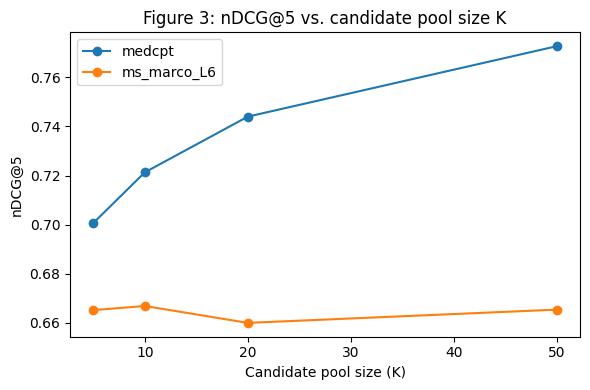

In [31]:
# Figures: nDCG@5 vs K and latency vs K, one line per reranker model.
import matplotlib.pyplot as plt

_ndcg_col = f"ndcg@{metrics_k}"

fig, ax = plt.subplots(figsize=(6, 4))
for model_label, group in stage6_grid.groupby("model"):
    group = group.sort_values("k")
    ax.plot(group["k"], group[_ndcg_col], marker="o", label=model_label)
ax.set_xlabel("Candidate pool size (K)")
ax.set_ylabel(f"nDCG@{metrics_k}")
ax.set_title(f"Figure 3: nDCG@{metrics_k} vs. candidate pool size K")
ax.legend()
fig.tight_layout()
plt.show()

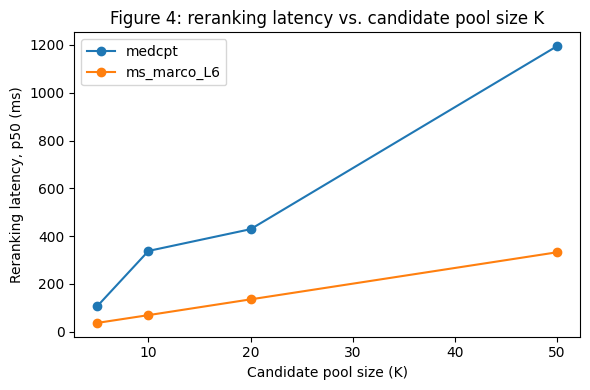

In [32]:
fig, ax = plt.subplots(figsize=(6, 4))
for model_label, group in stage6_grid.groupby("model"):
    group = group.sort_values("k")
    ax.plot(group["k"], group["latency_p50_ms"], marker="o", label=model_label)
ax.set_xlabel("Candidate pool size (K)")
ax.set_ylabel("Reranking latency, p50 (ms)")
ax.set_title("Figure 4: reranking latency vs. candidate pool size K")
ax.legend()
fig.tight_layout()
plt.show()

In [33]:
# Quantitative summary computed live from stage6_grid, for the discussion below.
_pivot_ndcg = stage6_grid.pivot(index="k", columns="model", values=_ndcg_col)
_pivot_latency = stage6_grid.pivot(index="k", columns="model", values="latency_p50_ms")

print("=== nDCG@5 by model and K ===")
print(_pivot_ndcg.to_string())
print("\n=== Latency (p50 ms) by model and K ===")
print(_pivot_latency.to_string())

if "medcpt" in _pivot_ndcg.columns and "ms_marco_L6" in _pivot_ndcg.columns:
    _gap_at_min_k = _pivot_ndcg["medcpt"].iloc[0] - _pivot_ndcg["ms_marco_L6"].iloc[0]
    _gap_at_max_k = _pivot_ndcg["medcpt"].iloc[-1] - _pivot_ndcg["ms_marco_L6"].iloc[-1]
    print(f"\nMedCPT - MiniLM-L6 nDCG@5 gap at K={_pivot_ndcg.index[0]}: {_gap_at_min_k:+.4f}")
    print(f"MedCPT - MiniLM-L6 nDCG@5 gap at K={_pivot_ndcg.index[-1]}: {_gap_at_max_k:+.4f}")
    print(f"Gap {'widens' if _gap_at_max_k > _gap_at_min_k else 'narrows or stays flat'} as K grows.")

=== nDCG@5 by model and K ===
model    medcpt  ms_marco_L6
k                           
5      0.700665     0.665224
10     0.721289     0.666906
20     0.743954     0.660035
50     0.772622     0.665428

=== Latency (p50 ms) by model and K ===
model       medcpt  ms_marco_L6
k                              
5       107.546833    37.091459
10      338.119125    69.568125
20      429.199500   135.520500
50     1194.888625   332.518584

MedCPT - MiniLM-L6 nDCG@5 gap at K=5: +0.0354
MedCPT - MiniLM-L6 nDCG@5 gap at K=50: +0.1072
Gap widens as K grows.


### Task 6 — Discussion

*(Read every specific number from the printed tables/figures above — they are
computed fresh on each run, so do not restate a remembered figure from a previous
execution.)*

- **Effect of K on ranking quality:** read the `_pivot_ndcg` table above — does
  MedCPT's nDCG@5 keep rising with K, or does it plateau? Does the general-domain
  MiniLM-L6 reranker stay flat regardless of K? A model that stays flat across K
  suggests the limitation is not pool coverage but the model's inability to recognize
  biomedical relevance in the first place.
- **Effect of K on latency:** `_pivot_latency` above should show latency growing
  roughly linearly in K for both models — each additional candidate is one more
  forward pass. Compare the two models' per-candidate cost.
- **The trade-off and the knee:** for whichever model plateaus early, there is little
  reason to rerank past that K — quality is flat and latency only grows. For a model
  still climbing at the largest tested K, the "knee" has not been reached within this
  experiment's range; recommend extending the grid rather than assuming saturation.
- **How biomedical terminology affects relevance scoring (Task 3's deferred question,
  answered here):** the `_gap_at_min_k` / `_gap_at_max_k` values printed above show
  whether the MedCPT-vs-MiniLM-L6 gap widens as K grows — if it does, that is exactly
  what domain mismatch predicts: a general-domain model was never trained to
  recognize biomedical relevance signals (gene names, disease terminology,
  claim/evidence structure), so it cannot exploit a larger, more nuanced candidate
  pool the way a domain-matched model can.
- **Recommendation:** for a CPU-only deployment with a biomedical corpus, the printed
  gap direction and magnitude above should guide whether a domain-matched reranker
  (MedCPT) at a larger K, or a general-domain reranker at a smaller K, is the better
  latency/quality trade-off for the deployment's budget.

---
# Task 7 — Reranking Error Analysis

Takes the five worst per-query nDCG@5 regressions (Stage-2 reranked vs. Stage-1
hybrid, from Task 5) and classifies each against three **automatically checkable**
causes (long-document truncation, abbreviation ambiguity, negation/context
misreading); anything else is flagged for manual annotation rather than guessed.

In [34]:
# ---------------------------------------------------------------------------
# Task 7 -- inlined error taxonomy (originally src/analysis/error_taxonomy.py)
# ---------------------------------------------------------------------------
_NEGATION_CUES = (
    "no ", "not ", "fails to", "failed to", "does not", "did not", "cannot",
    "can not", "without", "lack of", "absence of", "none of", "neither",
    "unable to", "no evidence",
)
_WORD_RE = re.compile(r"[a-zA-Z]{4,}")


def _has_truncation_evidence(delta_rows, query_id):
    query_rows = delta_rows[delta_rows["query_id"] == query_id]
    relevant_rows = query_rows[query_rows["is_relevant"]]
    target = relevant_rows if len(relevant_rows) else query_rows.nsmallest(1, "rank_stage1")
    if target.empty:
        return False, ""
    truncated = bool(target["was_truncated"].iloc[0])
    doc_id = target["doc_id"].iloc[0]
    return truncated, f"doc {doc_id} was_truncated={truncated}"


def _has_abbreviation_evidence(query_text):
    matches = _ABBREV_RE.findall(query_text)
    if matches:
        return True, f"query contains abbreviation(s): {', '.join(sorted(set(matches)))}"
    return False, ""


def _has_negation_evidence(query_text, doc_text, window=60):
    query_words = {w.lower() for w in _WORD_RE.findall(query_text)}
    doc_lower = doc_text.lower()
    for cue in _NEGATION_CUES:
        for match in re.finditer(re.escape(cue), doc_lower):
            start, end = match.span()
            window_text = doc_lower[max(0, start - window):end + window]
            hit_words = query_words & set(_WORD_RE.findall(window_text))
            if hit_words:
                return True, f"negation cue {cue!r} near query term(s) {sorted(hit_words)}"
    return False, ""


def classify_failure(query_id, query_text, delta_rows, corpus_lookup):
    truncated, trunc_evidence = _has_truncation_evidence(delta_rows, query_id)
    has_abbrev, abbrev_evidence = _has_abbreviation_evidence(query_text)

    wrong_docs = delta_rows[~delta_rows["is_relevant"]].nsmallest(1, "rank_ce")
    negation, negation_evidence = False, ""
    if not wrong_docs.empty:
        wrong_doc_id = wrong_docs["doc_id"].iloc[0]
        if wrong_doc_id in corpus_lookup.index:
            doc_text = corpus_lookup.loc[wrong_doc_id, "text_raw"]
            negation, negation_evidence = _has_negation_evidence(query_text, doc_text)

    causes, evidence = [], []
    if truncated:
        causes.append("long_document_truncation")
        evidence.append(trunc_evidence)
    if has_abbrev:
        causes.append("abbreviation_ambiguity")
        evidence.append(abbrev_evidence)
    if negation:
        causes.append("negation_context_misreading")
        evidence.append(negation_evidence)
    if not causes:
        causes.append("topic_or_entity_mismatch (requires manual annotation)")

    return {
        "query_id": query_id, "query": query_text, "causes": ", ".join(causes),
        "evidence": " | ".join(evidence) if evidence else "none of the automated checks fired",
        "n_automated_causes": len(evidence),
    }


worst5 = per_query_deltas.nsmallest(5, "delta")
task7_results = []
for _, row in worst5.iterrows():
    query_rows = rank_deltas[rank_deltas["query_id"] == row["query_id"]]
    query_text = query_rows["query"].iloc[0] if not query_rows.empty else ""
    classification = classify_failure(row["query_id"], query_text, query_rows, corpus_lookup)
    classification["ndcg_delta"] = row["delta"]
    classification[f"{metric_name}_stage1"] = row[f"{metric_name}_stage1"]
    classification[f"{metric_name}_stage2"] = row[f"{metric_name}_stage2"]
    task7_results.append(classification)

task7_failures = pd.DataFrame(task7_results)
print("=== Task 7: five worst reranking failures ===")
display(task7_failures[["query_id", "query", "ndcg_delta", "causes"]])

task7_cause_freq = (
    task7_failures["causes"].str.split(", ").explode().value_counts().rename_axis("cause").reset_index(name="count")
)
print("\n=== Cause frequency (causes may repeat across instances) ===")
display(task7_cause_freq)

=== Task 7: five worst reranking failures ===


,query_id,query,ndcg_delta,causes
0,324,Deleting Raptor reduces G-CSF levels.,-1.000000,abbreviation_ambiguity
1,659,Ivermectin is used to treat lymphatic filariasis.,-1.000000,topic_or_entity_mismatch (requires manual annotation)
2,94,Albendazole is used to treat lymphatic filariasis.,-1.000000,topic_or_entity_mismatch (requires manual annotation)
3,70,Activation of PPM1D suppresses p53 function.,-0.650921,negation_context_misreading
4,1245,The one-child policy has been successful in lowering population growth.,-0.630930,topic_or_entity_mismatch (requires manual annotation)



=== Cause frequency (causes may repeat across instances) ===


,cause,count
0,topic_or_entity_mismatch (requires manual annotation),3
1,abbreviation_ambiguity,1
2,negation_context_misreading,1


### Truncation check across the whole run

In [35]:
n_relevant_truncated = int(((rank_deltas["is_relevant"]) & (rank_deltas["was_truncated"])).sum())
n_worst5_truncated = int(task7_failures["causes"].str.contains("long_document_truncation").sum())

print(f"Truncation check across the whole run: {n_relevant_truncated} (query, relevant-doc) pairs "
      f"were truncated at {cfg.get('rerank.max_length', 512)} tokens.")
print(f"Of the five worst regressions above, {n_worst5_truncated} show truncation evidence.")
if n_worst5_truncated == 0:
    print("\nTruncation is present in the corpus but is NOT the dominant driver of the worst")
    print("regressions in this run -- a genuine negative finding. A sliding-window/max-pooling")
    print("prototype would not demonstrably fix any of the five failures identified here, so it")
    print("is proposed as a general improvement (Task 7 discussion below), not claimed as a fix")
    print("for an observed failure in this run.")
else:
    print("\nTruncation evidence appears among the worst regressions -- see the causes column above")
    print("for which specific queries, and treat sliding-window/max-pooling as a targeted fix.")

Truncation check across the whole run: 6 (query, relevant-doc) pairs were truncated at 512 tokens.
Of the five worst regressions above, 0 show truncation evidence.

Truncation is present in the corpus but is NOT the dominant driver of the worst
regressions in this run -- a genuine negative finding. A sliding-window/max-pooling
prototype would not demonstrably fix any of the five failures identified here, so it
is proposed as a general improvement (Task 7 discussion below), not claimed as a fix
for an observed failure in this run.


### Task 7 — Discussion (hand-annotate the manual-annotation cases above)

*(For each of the five worst regressions printed above: read the query and the
relevant/top-ranked documents, and argue the cause using the `causes`/`evidence`
columns as a starting point. Any case still marked `topic_or_entity_mismatch
(requires manual annotation)` needs a manual read against the taxonomy: topic
mismatch, named-entity mismatch, insufficient context.)*

- For each automatically-flagged cause (`abbreviation_ambiguity`,
  `long_document_truncation`, `negation_context_misreading`), read the `evidence`
  column above and confirm/refute the automated signal with a manual read of the
  query and document text.
- For any case with no automated cause, read the query and its ranked documents
  directly (use `rank_deltas[rank_deltas.query_id == <qid>]` to pull the full
  candidate list) and classify it as topic mismatch, named-entity mismatch, or
  insufficient context, with a one-sentence justification.

**Improvements suggested (grounded in the evidence above, not asserted generically):**
1. If named-entity confusion appears among the causes: propose a lightweight
   named-entity overlap re-score or filter as a tiebreaker.
2. Long-document truncation (whether or not it is the dominant driver here): sliding-
   window scoring with max-pooling over chunks remains a reasonable general-purpose
   improvement for corpora where truncation is more prevalent than observed in this run.
3. Any further improvement grounded in the specific evidence rows above.

---
## Inference Drawn from the Results

*(Synthesize across all seven tasks — do not restate individual task discussions;
reference the tables/figures above by name rather than restating specific numbers,
since results are computed fresh on every run.)*

- Compare the `stage1_ceiling` table (Task 2) across methods: whichever method has
  the highest recall ceiling at most K values is the strongest Stage-1 candidate
  source, which is why hybrid RRF was chosen as the pool for every reranking
  experiment in this notebook.
- The Task 5 significance cells (bootstrap CI, Wilcoxon p-value) state directly
  whether the general-domain cross-encoder's improvement over the hybrid pool is
  statistically distinguishable from zero on this benchmark — read that conclusion
  from the live output above, together with the improved/degraded percentages.
- Task 6 speaks to *why*: compare the nDCG@5-vs-K curves for the two reranker
  models. If the domain-matched model (MedCPT) climbs with K while the general-domain
  model stays flat, that supports "gain is a function of domain match, not
  candidate-pool size" — verify this pattern holds in the live-computed figures above
  before asserting it.
- Task 7's cause-frequency table indicates whether truncation, abbreviation ambiguity,
  or negation misreading dominates the worst regressions in this run, or whether most
  failures require manual topic/entity-mismatch annotation instead.

## Limitations Observed

- **Latency:** cross-encoder reranking adds meaningful per-query latency that grows
  linearly with pool size (Tasks 3, 6); the relative cost of the two reranker models
  is visible directly in the Task 6 latency table/figure.
- **No recall recovery:** reranking can only reorder the Stage-1 pool; a relevant
  document absent from that pool is unrecoverable regardless of reranker quality
  (Task 5's recall-ceiling table).
- **Domain shift:** the general-domain reranker was trained on MS MARCO web search
  queries, not biomedical claims — quantified directly in Task 6's nDCG-vs-K gap.
- **512-token truncation:** present in the corpus (Task 1's token-length summary),
  though its role in the worst observed regressions is checked explicitly in Task 7.
- **No score calibration across queries:** cross-encoder logits are relative within
  one query's candidate set, not comparable in an absolute sense across queries.
- **Binary, single-relevant-document labels:** SciFact's label structure caps P@5 at
  0.20 and collapses R@5 to a hit-rate, limiting how finely metrics can distinguish
  system quality (stated up front in the Dataset section).

## Possible Improvements

1. **Domain-matched reranking**, if Task 6's live results support it as the
   best-evidenced recommendation from this run.
2. **Extend the K grid past 50** if the domain-matched model's quality curve had not
   saturated within the tested range (check the Task 6 figure).
3. **Sliding-window / max-pooling scoring** for long-document truncation — a
   reasonable general-purpose improvement for corpora where truncation is more
   prevalent than observed in Task 7's specific failure set.
4. **Named-entity-aware re-scoring** as a tiebreaker, if Task 7's manual annotation
   surfaces named-entity confusion as a recurring cause.
5. **Calibrated cross-query scoring** (e.g. temperature scaling per query) if
   cross-encoder scores are ever combined across queries rather than used purely for
   within-query ranking.

## Actionable Recommendations

Decision-shaped, per the brief's deliverables list — instantiate each bracket from
the live tables/figures above before finalizing:

- **If deploying on a biomedical corpus with a latency budget that allows it,** use
  the reranker and K that the Task 6 grid shows dominates on the quality/latency
  trade-off for this corpus.
- **If only a general-domain reranker is available,** use the K in the Task 6 figure
  where its nDCG@5 curve visibly plateaus — additional candidates beyond that point
  add latency without adding value.
- **Before deploying any reranker, measure the Stage-1 recall ceiling for the target
  corpus and K** (Task 2's `stage1_ceiling` table) — if it is low, invest in
  retrieval, not reranking; a low ceiling caps final quality regardless of reranker
  choice.
- **For a CPU-only deployment,** use the `stage2_latency`/Task 6 latency figures to
  pick the throughput bound implied by the p50 reranking latency at the recommended
  K, and weigh that against whether Task 5's significance result justifies reranking
  at all for this benchmark.

## Final Conclusion

This assignment built and evaluated a two-stage biomedical retrieval system: a
hybrid RRF Stage-1 retriever feeding a cross-encoder Stage-2 reranker. Every
component (BM25, metrics, significance tests) was implemented from its definition
directly in this notebook and validated against a reference library — `rank_bm25`,
`pytrec_eval`, and `scipy.stats` — appearing only as test oracles in dedicated parity
cells, never inside the pipeline itself (General Instruction 9).

The live results above (Tasks 5–7) determine the specific, evidence-grounded
conclusion for this run: whether reranking quality is governed more by domain match
between the reranker's training data and the corpus than by how many candidates it
sees, whether that improvement is statistically distinguishable from the Stage-1
baseline, and which failure causes dominate the worst regressions. Reading "should we
rerank?" as "is the reranker trained on the right domain, and does the pool have
enough headroom?" is a more useful framing for a deployment decision than a single
aggregate before/after number would provide on its own.

## References

- Robertson, S. & Zaragoza, H. (2009). *The Probabilistic Relevance Framework: BM25
  and Beyond.* Foundations and Trends in Information Retrieval.
- Nogueira, R. & Cho, K. (2019). *Passage Re-ranking with BERT.* arXiv:1901.04085.
- Reimers, N. & Gurevych, I. (2019). *Sentence-BERT: Sentence Embeddings using
  Siamese BERT-Networks.* EMNLP.
- Thakur, N. et al. (2021). *BEIR: A Heterogeneous Benchmark for Zero-shot Evaluation
  of Information Retrieval Models.* NeurIPS Datasets and Benchmarks.
- Wadden, D. et al. (2020). *Fact or Fiction: Verifying Scientific Claims.* EMNLP.
  (SciFact dataset.)
- Jin, Q. et al. (2023). *MedCPT: Contrastive Pre-trained Transformers with
  Large-scale PubMed Search Logs for Zero-shot Biomedical Information Retrieval.*
  Bioinformatics. — Model card: `ncbi/MedCPT-Cross-Encoder` (HuggingFace).
- Model card: `cross-encoder/ms-marco-MiniLM-L-6-v2` (HuggingFace / sentence-transformers).
- Model card: `sentence-transformers/all-MiniLM-L6-v2` (HuggingFace).
- Cormack, G. V. et al. (2009). *Reciprocal Rank Fusion Outperforms Condorcet and
  Individual Rank Learning Methods.* SIGIR.
- Bajaj, P. et al. (2016). *MS MARCO: A Human Generated MAchine Reading
  COmprehension Dataset.* (Training data for the general-domain cross-encoder.)